### Importing the Libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

### Loading the Dataset:

In [1]:
import pandas as pd
import numpy as np

# Define the file path
file_path = r'B:/3. Prog/2. Projects/7. Logistics and supply chain/Master_Logistics_1M_Rows.csv'

# Load the data
df = pd.read_csv(file_path)

# Verify the ingestion
print(df.info())
print(f"\nTotal rows loaded: {len(df)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 27 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   timestamp                        object 
 1   vehicle_gps_latitude             float64
 2   vehicle_gps_longitude            float64
 3   fuel_consumption_rate            float64
 4   eta_variation_hours              float64
 5   traffic_congestion_level         float64
 6   warehouse_inventory_level        float64
 7   loading_unloading_time           float64
 8   handling_equipment_availability  float64
 9   order_fulfillment_status         float64
 10  weather_condition_severity       float64
 11  port_congestion_level            float64
 12  shipping_costs                   float64
 13  supplier_reliability_score       float64
 14  lead_time_days                   float64
 15  historical_demand                float64
 16  iot_temperature                  float64
 17  cargo_co

### Structure Inspection:

In [2]:
from IPython.display import display

# Display basic structure and data types
print("--- Dataset Info ---")
display(df.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 27 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   timestamp                        object 
 1   vehicle_gps_latitude             float64
 2   vehicle_gps_longitude            float64
 3   fuel_consumption_rate            float64
 4   eta_variation_hours              float64
 5   traffic_congestion_level         float64
 6   warehouse_inventory_level        float64
 7   loading_unloading_time           float64
 8   handling_equipment_availability  float64
 9   order_fulfillment_status         float64
 10  weather_condition_severity       float64
 11  port_congestion_level            float64
 12  shipping_costs                   float64
 13  supplier_reliability_score       float64
 14  lead_time_days                   float64
 15  historical_demand                float64
 16  iot_temperature                  

None

In [3]:
from IPython.display import display

# This renders the summary as an interactive, scrollable HTML table
print("--- Summary Statistics ---")
display(df.describe().round(4).T)

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
vehicle_gps_latitude,4995000.0,3.802860e+01,6.919400e+00,2.969830e+01,3.128520e+01,3.642350e+01,4.446640e+01,5.030310e+01
vehicle_gps_longitude,4995000.0,-9.011670e+01,1.736810e+01,-1.207052e+02,-1.062570e+02,-8.629660e+01,-7.308630e+01,-6.916270e+01
fuel_consumption_rate,4995000.0,8.010600e+00,4.266600e+00,4.788400e+00,5.044100e+00,5.637500e+00,9.662000e+00,2.013020e+01
eta_variation_hours,4995000.0,2.891600e+00,2.275100e+00,-2.087100e+00,1.180100e+00,3.881200e+00,4.882100e+00,5.113900e+00
traffic_congestion_level,4995000.0,4.993200e+00,3.532000e+00,-1.613000e-01,1.478300e+00,4.987000e+00,8.533100e+00,1.015350e+01
warehouse_inventory_level,4995000.0,2.993329e+02,3.234580e+02,-1.520940e+01,1.638320e+01,1.576301e+02,5.408598e+02,1.011100e+03
loading_unloading_time,4995000.0,2.292500e+00,1.554200e+00,4.343000e-01,7.755000e-01,1.920200e+00,3.736400e+00,5.065500e+00
handling_equipment_availability,4995000.0,3.025000e-01,3.257000e-01,-1.490000e-02,1.720000e-02,1.598000e-01,5.526000e-01,1.012500e+00
order_fulfillment_status,4995000.0,6.008000e-01,3.456000e-01,-1.440000e-02,2.774000e-01,6.809000e-01,9.382000e-01,1.015200e+00
weather_condition_severity,4995000.0,4.974000e-01,3.533000e-01,-1.620000e-02,1.438000e-01,4.960000e-01,8.494000e-01,1.015800e+00


In [4]:
from IPython.display import display

# Convert shape (rows, cols) into a 1-row DataFrame for the sliding UI
shape_df = pd.DataFrame([df.shape], columns=['Total Rows', 'Total Columns'])

print("--- Dataset Shape ---")
display(shape_df)

--- Dataset Shape ---


,Total Rows,Total Columns
0,5000000,27


In [5]:
from IPython.display import display

# 1. Create a metadata summary DataFrame
info_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})

print(f"--- Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns ---")

# 2. Display the interactive table (scrollable in most IDEs)
display(info_df)

--- Dataset Shape: 5000000 rows x 27 columns ---


,Column,Data Type,Non-Null Count,Null Count,Unique Values
0,timestamp,object,5000000,0,67276
1,vehicle_gps_latitude,float64,4995000,5000,4995000
2,vehicle_gps_longitude,float64,4995000,5000,4995000
3,fuel_consumption_rate,float64,4995000,5000,4995000
4,eta_variation_hours,float64,4995000,5000,4995000
5,traffic_congestion_level,float64,4995000,5000,4995000
6,warehouse_inventory_level,float64,4995000,5000,4995000
7,loading_unloading_time,float64,4995000,5000,4995000
8,handling_equipment_availability,float64,4995000,5000,4995000
9,order_fulfillment_status,float64,4995000,5000,4995000


### Creating a mirror dataset:

In [20]:
# Create the mirror dataframe
df_mirror = df.copy()

# Save the mirror as a flat file for the project audit trail
df_mirror.to_csv('Master_Logistics_Mirror.csv', index=False)
print("\nMirror file 'Master_Logistics_Mirror.csv' created successfully.")


Mirror file 'Master_Logistics_Mirror.csv' created successfully.


### Loading the df_mirror file:

In [32]:
# Define the file path
file_path = r"B:\3. Prog\2. Projects\7. Logistics and supply chain\Master_Logistics_Mirror.csv"

df_mirror = pd.read_csv(file_path)

### Checking the structure of the Mirror file:

In [9]:
# Display basic structure and data types
print("--- Dataset Info ---")
print(df_mirror.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 27 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   timestamp                        object 
 1   vehicle_gps_latitude             float64
 2   vehicle_gps_longitude            float64
 3   fuel_consumption_rate            float64
 4   eta_variation_hours              float64
 5   traffic_congestion_level         float64
 6   warehouse_inventory_level        float64
 7   loading_unloading_time           float64
 8   handling_equipment_availability  float64
 9   order_fulfillment_status         float64
 10  weather_condition_severity       float64
 11  port_congestion_level            float64
 12  shipping_costs                   float64
 13  supplier_reliability_score       float64
 14  lead_time_days                   float64
 15  historical_demand                float64
 16  iot_temperature                  

In [26]:
from IPython.display import display

# This renders the summary as an interactive, scrollable HTML table
print("--- Summary Statistics ---")
display(df_mirror.describe().round(4).T)

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
vehicle_gps_latitude,4995000.0,3.802860e+01,6.919400e+00,2.969830e+01,3.128520e+01,3.642350e+01,4.446640e+01,5.030310e+01
vehicle_gps_longitude,4995000.0,-9.011670e+01,1.736810e+01,-1.207052e+02,-1.062570e+02,-8.629660e+01,-7.308630e+01,-6.916270e+01
fuel_consumption_rate,4995000.0,8.010600e+00,4.266600e+00,4.788400e+00,5.044100e+00,5.637500e+00,9.662000e+00,2.013020e+01
eta_variation_hours,4995000.0,2.891600e+00,2.275100e+00,-2.087100e+00,1.180100e+00,3.881200e+00,4.882100e+00,5.113900e+00
traffic_congestion_level,4995000.0,4.993200e+00,3.532000e+00,-1.613000e-01,1.478300e+00,4.987000e+00,8.533100e+00,1.015350e+01
warehouse_inventory_level,4995000.0,2.993329e+02,3.234580e+02,-1.520940e+01,1.638320e+01,1.576301e+02,5.408598e+02,1.011100e+03
loading_unloading_time,4995000.0,2.292500e+00,1.554200e+00,4.343000e-01,7.755000e-01,1.920200e+00,3.736400e+00,5.065500e+00
handling_equipment_availability,4995000.0,3.025000e-01,3.257000e-01,-1.490000e-02,1.720000e-02,1.598000e-01,5.526000e-01,1.012500e+00
order_fulfillment_status,4995000.0,6.008000e-01,3.456000e-01,-1.440000e-02,2.774000e-01,6.809000e-01,9.382000e-01,1.015200e+00
weather_condition_severity,4995000.0,4.974000e-01,3.533000e-01,-1.620000e-02,1.438000e-01,4.960000e-01,8.494000e-01,1.015800e+00


In [10]:
from IPython.display import display

# Convert shape (rows, cols) into a 1-row DataFrame for the sliding UI
shape_df = pd.DataFrame([df_mirror.shape], columns=['Total Rows', 'Total Columns'])

print("--- Dataset Shape ---")
display(shape_df)

--- Dataset Shape ---


,Total Rows,Total Columns
0,5000000,27


In [11]:
from IPython.display import display

# 1. Create a metadata summary DataFrame
info_df = pd.DataFrame({
    'Column': df_mirror.columns,
    'Data Type': df_mirror.dtypes.values,
    'Non-Null Count': df_mirror.notnull().sum().values,
    'Null Count': df_mirror.isnull().sum().values,
    'Unique Values': df_mirror.nunique().values
})

print(f"--- Dataset Shape: {df_mirror.shape[0]} rows x {df_mirror.shape[1]} columns ---")

# 2. Display the interactive table (scrollable in most IDEs)
display(info_df)

--- Dataset Shape: 5000000 rows x 27 columns ---


,Column,Data Type,Non-Null Count,Null Count,Unique Values
0,timestamp,object,5000000,0,67276
1,vehicle_gps_latitude,float64,4995000,5000,4995000
2,vehicle_gps_longitude,float64,4995000,5000,4995000
3,fuel_consumption_rate,float64,4995000,5000,4995000
4,eta_variation_hours,float64,4995000,5000,4995000
5,traffic_congestion_level,float64,4995000,5000,4995000
6,warehouse_inventory_level,float64,4995000,5000,4995000
7,loading_unloading_time,float64,4995000,5000,4995000
8,handling_equipment_availability,float64,4995000,5000,4995000
9,order_fulfillment_status,float64,4995000,5000,4995000


The structural information you provided exposes significant Data Quality (DQ) Red Flags and Data Integrity issues. Here is the detailed breakdown of the insights gained from this audit:

**1. Systematic Data Corruption (The 5,000 Gap)**

A. The Observation: Except for timestamp and Shipment_ID, every single column has exactly 5,000 Null Values ($5,000,000 - 4,995,000 = 5,000$).

The Insight: This is not random noise. A 0.1% loss across all features simultaneously suggests a failed join, a corrupt file footer, or a process interruption during the creation of the mirror file.

Actionable Red Flag: You must investigate the last 5,000 rows of your file; they likely contain empty strings or NaN values.

**2. Domain Logic Violations (Impossible Physical Values)**

The summary statistics show values that are physically or logically impossible in a logistics environment:

A. Negative Inventory: warehouse_inventory_level has a minimum of -15.21. Physical stock cannot be less than zero.

B. Negative Congestion: traffic_congestion_level has a minimum of -0.16. Congestion levels are typically indexed from 0 upwards.

C. Score Boundary Leaks: handling_equipment_availability, order_fulfillment_status, and weather_condition_severity all show negative minimums (e.g., -0.01) and maximums exceeding 1.0 (e.g., 1.01).

The Insight: These columns were likely generated via a mathematical simulation or a scaling function that lacked "clipping" (e.g., ensuring values stay between 0 and 1).

**3. Floating-Point Anomalies**

The Observation: For columns 1 through 23, the unique Value count is exactly 4,995,000.

A. The Insight: In a real-world dataset of 5 million rows, you would expect some overlap in values like traffic_congestion_level or fuel_consumption_rate. Having every single non-null value be unique suggests these are high-precision synthetic floats.

Red Flag: This high cardinality will make indexing and grouping operations in DuckDB or Power BI significantly slower and may consume more memory than necessary.

**4. Schema & Data Type Risks**

A. timestamp as Object: It is currently stored as a string (object).

Risk: You cannot perform time-series analysis, hourly grouping, or lead-time calculations until this is cast to a datetime format.

B. delivery_time_deviation Cardinality: While other metrics have 4,995,000 unique values, this one has 4,970,026.

The Insight: There are roughly 24,974 repeating values here. This column behaves differently than the others and requires a closer look to see if it contains specific "error codes" or "rounded" placeholders.

### Data Inconsistency Check:

**1. Natural Inconsistencies:**

**A. Null Values:**

In [3]:
import pandas as pd

# Calculate Null counts and percentages
total_rows = len(df_mirror)
null_data = df_mirror.isnull().sum()
null_percent = (null_data / total_rows) * 100

# Create a summary DataFrame for the "Sliding Table" view
null_report = pd.DataFrame({
    'Total Nulls': null_data,
    'Percentage (%)': null_percent.round(4)
}).sort_values(by='Total Nulls', ascending=False)

# Filter to show only columns that actually have nulls
null_report = null_report[null_report['Total Nulls'] > 0]

print("--- [GROUP A] NULL VALUE INSPECTION ---")
if not null_report.empty:
    display(null_report)
else:
    print("Clean Slate: No Null values detected.")

# Check for "Completely Empty Rows" (Systemic Failure Check)
empty_rows_count = df_mirror.isnull().all(axis=1).sum()
empty_rows_pct = (empty_rows_count / total_rows) * 100
print(f"\nSystemic Failure (Entirely Empty Rows): {empty_rows_count} ({empty_rows_pct:.4f}%)")

--- [GROUP A] NULL VALUE INSPECTION ---


,Total Nulls,Percentage (%)
vehicle_gps_latitude,5000,0.1
vehicle_gps_longitude,5000,0.1
fuel_consumption_rate,5000,0.1
loading_unloading_time,5000,0.1
eta_variation_hours,5000,0.1
traffic_congestion_level,5000,0.1
warehouse_inventory_level,5000,0.1
order_fulfillment_status,5000,0.1
handling_equipment_availability,5000,0.1
weather_condition_severity,5000,0.1



Systemic Failure (Entirely Empty Rows): 0 (0.0000%)


**Note -** The uniformity of these results—exactly 5,000 nulls across every single column except for the primary keys—is a textbook example of a systemic data event.

**Possible Cause -** Partial Data Injection / File Truncation. Since the count is a perfectly round number ($5,000$) and is consistent across all features, this wasn't a random sensor failure. Most likely, the data generation script or the export process was interrupted, or a specific batch of $5,000$ records failed to join with the master metadata during the "mirroring" process.

**Impact -** Reduced Statistical Power. While $0.1\%$ seems small, the loss of $5,000$ full rows of operational data means any subsequent analysis (like average fuel consumption or total shipping costs) is slightly skewed. Because the nulls are uniform across rows, you effectively have $5,000$ "Ghost Rows" that provide no insight but take up index space.

**Significance -** High (Structural Integrity). This is a "Red Flag" for the reliability of the data pipeline. If this were a real-world scenario, it would indicate that the data collection system is dropping entire packets of information rather than individual sensor pings.



**B. Checking Duplicates:**

In [4]:
import pandas as pd

total_rows = len(df_mirror)

# Identify columns that have at least one duplicate value
duplicate_cols = [col for col in df_mirror.columns if df_mirror[col].duplicated().any()]

# Calculate counts and percentages for those specific columns
results = []
for col in duplicate_cols:
    count = df_mirror[col].duplicated().sum()
    results.append({
        'Column': col,
        'Duplicate Count': count,
        'Percentage (%)': (count / total_rows) * 100
    })

# Display as a table
duplicate_tag_report = pd.DataFrame(results).sort_values(by='Duplicate Count', ascending=False)

print("--- [GROUP A] COLUMNS WITH DUPLICATES ---")
display(duplicate_tag_report)

--- [GROUP A] COLUMNS WITH DUPLICATES ---


,Column,Duplicate Count,Percentage (%)
24,risk_classification,4999992,99.99984
0,timestamp,4932724,98.65448
25,delivery_time_deviation,29973,0.59946
3,fuel_consumption_rate,4999,0.09998
2,vehicle_gps_longitude,4999,0.09998
5,traffic_congestion_level,4999,0.09998
6,warehouse_inventory_level,4999,0.09998
7,loading_unloading_time,4999,0.09998
4,eta_variation_hours,4999,0.09998
1,vehicle_gps_latitude,4999,0.09998


**Possible Cause -** Null Collision & Low Cardinality. The 4,999 duplicates across all numeric columns are almost certainly the 5,000 Nulls we found earlier (Pandas counts the second null as a duplicate of the first, so $5,000 - 1 = 4,999$). The 98.65% in timestamp and 99.99% in risk_classification are expected for categorical/time data with a limited range of possible values.

**Impact -** Statistical Distortion. High duplication in timestamp means many events are overlapping, which is fine for logistics. However, the 0.60% duplicates in delivery_time_deviation (a high-precision float) are more concerning—this suggests either specific "error states" are repeating or the generator recycled specific calculation results.

**Significance -** Moderate (Systemic). The duplicates in the numeric columns are a byproduct of the Null issue rather than independent errors. The high duplication in risk_classification is normal (only 7 unique values exist), but the $29,973$ duplicates in delivery_time_deviation warrant a check to ensure they aren't placeholder values (like -999).

**C. Whitespace, Special Characters, and Letter Casing:**

In [5]:
import pandas as pd

total_rows = len(df_mirror)
string_cols = df_mirror.select_dtypes(include=['object']).columns
results = []

for col in string_cols:
    # Check for leading/trailing whitespace
    whitespace_count = df_mirror[df_mirror[col].astype(str).str.strip() != df_mirror[col].astype(str)].shape[0]
    
    # Check for inconsistent casing (by comparing unique values in lowercase)
    raw_unique = df_mirror[col].astype(str).nunique()
    lower_unique = df_mirror[col].astype(str).str.lower().nunique()
    casing_issue = "Yes" if raw_unique != lower_unique else "No"
    
    if whitespace_count > 0 or casing_issue == "Yes":
        results.append({
            'Column': col,
            'Whitespace Rows': whitespace_count,
            'Casing Inconsistency': casing_issue,
            'Percentage (%)': (whitespace_count / total_rows) * 100
        })

print("--- [GROUP A] WHITESPACE & CASING INSPECTION ---")
if results:
    display(pd.DataFrame(results))
else:
    print("No whitespace or casing issues detected in string columns.")

--- [GROUP A] WHITESPACE & CASING INSPECTION ---


,Column,Whitespace Rows,Casing Inconsistency,Percentage (%)
0,risk_classification,75093,Yes,1.50186


In [6]:
import pandas as pd
import re

total_rows = len(df_mirror)
string_cols = df_mirror.select_dtypes(include=['object']).columns
# This regex flags anything that is NOT a letter, number, space, or date separator (- :)
symbol_regex = r'[^a-zA-Z0-9\s\-\:]'

results = []

for col in string_cols:
    # Identify rows containing special characters
    symbol_hits = df_mirror[df_mirror[col].astype(str).str.contains(symbol_regex, na=False, regex=True)]
    count = len(symbol_hits)
    
    if count > 0:
        # Grab a unique sample of the "junk" to see what it looks like
        sample_junk = symbol_hits[col].unique()[:2]
        results.append({
            'Column': col,
            'Special Char Count': count,
            'Percentage (%)': (count / total_rows) * 100,
            'Sample Found': sample_junk
        })

print("--- [GROUP A] SPECIAL CHARACTER INSPECTION ---")
if results:
    display(pd.DataFrame(results))
else:
    print("Clean: No unexpected special characters detected.")

--- [GROUP A] SPECIAL CHARACTER INSPECTION ---
Clean: No unexpected special characters detected.


**Note -** The clean result for special characters is a good sign, but the 1.5% error rate in risk_classification formatting is a classic "silent killer" for data visualization and reporting.

**Possible Cause -** Formatting Logic Variance. The presence of both whitespace (e.g., "Low Risk ") and casing issues (e.g., "low risk" vs "Low Risk") suggests the synthetic generator likely used multiple source lists or lacked a "strip and capitalize" function during the final data assembly.

** Impact -** Categorical Fragmentation. When you pull this into a dashboard (like Power BI or Tableau), the system will treat "Low Risk", "low risk", and "Low Risk " as three different categories. This will lead to incorrect shipment counts and skewed risk-assessment percentages.

**Significance -** Moderate. While it doesn't cause system crashes, it directly compromises the reliability of business insights. Any "Total High Risk Shipments" calculation will be under-reported unless the data is cleaned.

**D. Schema Inconsistencies:**

In [7]:
import pandas as pd

total_rows = len(df_mirror)
results = []

# 1. Check if 'timestamp' is parseable but currently an object
is_timestamp_obj = df_mirror['timestamp'].dtype == 'object'
try:
    # Attempt to parse a sample to see if it SHOULD be datetime
    pd.to_datetime(df_mirror['timestamp'].head(10), errors='raise')
    schema_status = "Incorrect (Stored as Object, should be Datetime)" if is_timestamp_obj else "Correct"
except:
    schema_status = "Corrupt (Unparseable strings in timestamp)"

if is_timestamp_obj:
    results.append({
        'Column': 'timestamp',
        'Current Type': 'object',
        'Expected Type': 'datetime64',
        'Status': schema_status
    })

# 2. Check for Numeric Precision "Creep" 
# (Floats that are actually Integers - e.g., 5.0, 10.0)
float_cols = df_mirror.select_dtypes(include=['float64']).columns
for col in float_cols:
    # Check if all non-null values have no decimal remainder
    if (df_mirror[col].dropna() % 1 == 0).all():
        results.append({
            'Column': col,
            'Current Type': 'float64',
            'Expected Type': 'int64',
            'Status': 'Inefficient (Integer data stored as Float)'
        })

print("--- [GROUP A] SCHEMA INCONSISTENCY INSPECTION ---")
if results:
    display(pd.DataFrame(results))
else:
    print("Schema is optimized for all analyzed columns.")

--- [GROUP A] SCHEMA INCONSISTENCY INSPECTION ---


,Column,Current Type,Expected Type,Status
0,timestamp,object,datetime64,"Incorrect (Stored as Object, should be Datetime)"


In [8]:
import pandas as pd

total_rows = len(df_mirror)
results = []

# Audit every column for its true nature vs. its technical Dtype
for col in df_mirror.columns:
    current_dtype = str(df_mirror[col].dtype)
    
    # 1. Check for Mixed Types in Object Columns (The "Hidden Number" trap)
    if current_dtype == 'object':
        # Count how many values are actually numeric strings
        numeric_count = pd.to_numeric(df_mirror[col], errors='coerce').notnull().sum()
        
        if numeric_count > 0 and numeric_count < total_rows:
            results.append({
                'Column': col,
                'Current Type': current_dtype,
                'Issue': f"Mixed Data (Numeric found in String col)",
                'Affected Count': numeric_count
            })
        elif numeric_count == (total_rows - 5000): # Matching our known null count
             results.append({
                'Column': col,
                'Current Type': current_dtype,
                'Issue': "Schema Mismatch (Numeric data forced to Object)",
                'Affected Count': numeric_count
            })

# Summary of Schema Integrity
schema_audit = pd.DataFrame(results)

print("--- [GROUP A] DEEP SCHEMA INSPECTION ---")
if not schema_audit.empty:
    display(schema_audit)
else:
    print("No additional schema mismatches found in non-timestamp columns.")

--- [GROUP A] DEEP SCHEMA INSPECTION ---
No additional schema mismatches found in non-timestamp columns.


**Schema -** timestamp is a String. Significance is High. This prevents any time-series analysis or lead-time calculation until converted.

**Deep Integrity -** No mixed-type corruption. Significance is Low. This is good news; it means your numeric columns (Floats/Ints) aren't contaminated with hidden text strings.

**E. Unique Values: (Cardinality Audit)**

In [9]:
import pandas as pd

total_rows = len(df_mirror)
results = []

for col in df_mirror.columns:
    # Calculate unique values (excluding nulls)
    unique_count = df_mirror[col].nunique()
    # Calculate what percentage of the data is unique
    cardinality_ratio = (unique_count / (total_rows - df_mirror[col].isnull().sum())) * 100
    
    results.append({
        'Column': col,
        'Unique Values': unique_count,
        'Cardinality Ratio (%)': cardinality_ratio
    })

# Create the report
unique_report = pd.DataFrame(results).sort_values(by='Unique Values', ascending=False)

print("--- [GROUP A] UNIQUE VALUE (CARDINALITY) AUDIT ---")
display(unique_report)

--- [GROUP A] UNIQUE VALUE (CARDINALITY) AUDIT ---


,Column,Unique Values,Cardinality Ratio (%)
26,Shipment_ID,5000000,100.00000
2,vehicle_gps_longitude,4995000,100.00000
1,vehicle_gps_latitude,4995000,100.00000
7,loading_unloading_time,4995000,100.00000
4,eta_variation_hours,4995000,100.00000
5,traffic_congestion_level,4995000,100.00000
6,warehouse_inventory_level,4995000,100.00000
9,order_fulfillment_status,4995000,100.00000
8,handling_equipment_availability,4995000,100.00000
10,weather_condition_severity,4995000,100.00000


**Possible Cause -** Limited Seed Pool. Generators often use a "Seed" of 10,000 values and repeat them to reach 5M rows. If the unique count is significantly lower than the row count for non-categorical columns, the data lacks "Natural Entropy." The Shipment_ID reaching 5,000,000 confirms that the 5,000 null rows still have unique IDs assigned to them.

**Impact -** Model Overfitting. If a machine learning model sees the same "unique" float thousands of times, it will memorize the patterns rather than learning the logic. It also makes "Outlier" detection less effective. 100% uniqueness is "too perfect" and makes the data look like mathematical noise rather than operational records.

**Significance -** High. This determines the "Texture" of your data. Low cardinality in high-precision fields is a massive red flag for synthetic data quality. The 99.5% cardinality in delivery_time_deviation is the only "organic" looking metric here, as it implies about 25,000 rows share a value—likely due to a specific error state or placeholder being repeated.

**2. Functional Inconsistencies:**

**A. Placeholder Errors:**

In [10]:
import pandas as pd
import numpy as np

total_rows = len(df_mirror)
results = []

# Defining common placeholders used in synthetic data generation
placeholders = [-999, -1, 0, 9999, '0', 'N/A', 'Unknown', 'nan']

for col in df_mirror.columns:
    # Check if any value in the column matches our placeholder list
    # We cast to string for a universal comparison
    hit_mask = df_mirror[col].astype(str).str.strip().isin([str(p) for p in placeholders])
    count = hit_mask.sum()
    
    # We ignore the 5,000 true Nulls we already found
    actual_placeholders = count - df_mirror[col].isnull().sum() if str(np.nan) in [str(p) for p in placeholders] else count

    if actual_placeholders > 0:
        results.append({
            'Column': col,
            'Placeholder Count': actual_placeholders,
            'Percentage (%)': (actual_placeholders / total_rows) * 100,
            'Detected Values': df_mirror[col][hit_mask].unique()
        })

print("--- [GROUP B] PLACEHOLDER ERROR INSPECTION ---")
if results:
    display(pd.DataFrame(results).sort_values(by='Placeholder Count', ascending=False))
else:
    print("No common placeholders (0, -1, -999) detected.")

--- [GROUP B] PLACEHOLDER ERROR INSPECTION ---
No common placeholders (0, -1, -999) detected.


**Possible Cause -** Default Value Injection. Systems often cannot handle "null" mathematically, so developers set a default (like -999) to ensure the code keeps running. When a sensor fails to ping, the system often records a 0 or -1 instead of a Null. This is a "Functional" error because it allows calculations to run but produces wrong results.

**Impact -** Extreme Statistical Bias. If shipping_costs has a placeholder of 0, your average cost will be artificially low. If it uses 9999, your average will be sky-high. Unlike Nulls, these are invisible to standard .mean() functions and will ruin your analysis. A 0 in shipping_costs or fuel_consumption_rate will drag down your averages. Because these aren't Nulls, they won't be caught by standard "Missing Data" filters.

**Significance -** Critical. These must be converted to true NaN values before any further Group B (Functional) analysis can be trusted. These are "Logic Landmines." They look like data but act like errors.

**Note -** Combined with the 100% cardinality finding, we now know that every single row (outside of the 5,000 nulls) contains a unique, non-placeholder value.

**B. Outliers:**

In [11]:
import pandas as pd

total_rows = len(df_mirror)
# Target columns that drive business costs and operations
functional_cols = [
    'shipping_costs', 
    'fuel_consumption_rate', 
    'loading_unloading_time', 
    'warehouse_inventory_level',
    'historical_demand'
]

results = []

for col in functional_cols:
    Q1 = df_mirror[col].quantile(0.25)
    Q3 = df_mirror[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter for values outside the bounds
    outliers = df_mirror[(df_mirror[col] < lower_bound) | (df_mirror[col] > upper_bound)].dropna(subset=[col])
    count = len(outliers)
    
    if count > 0:
        results.append({
            'Column': col,
            'Outlier Count': count,
            'Percentage (%)': (count / total_rows) * 100,
            'Min Value': outliers[col].min(),
            'Max Value': outliers[col].max()
        })

print("--- [GROUP B] FUNCTIONAL OUTLIER INSPECTION (IQR) ---")
if results:
    display(pd.DataFrame(results).sort_values(by='Outlier Count', ascending=False))
else:
    print("No statistical outliers detected in functional columns.")

--- [GROUP B] FUNCTIONAL OUTLIER INSPECTION (IQR) ---


,Column,Outlier Count,Percentage (%),Min Value,Max Value
0,fuel_consumption_rate,403044,8.06088,16.588832,20.130232


**Possible Cause -** Bimodal Distribution / Fleet Variance. This doesn't look like "noise." It looks like the generator simulated two types of vehicles: a standard fleet and a "Heavy-Duty/Inefficient" fleet. Because the IQR method assumes a single "normal" cluster, it flags the entire inefficient group as outliers.

**Impact -** Cost Miscalculation. If these 403,044 rows represent a specific region or vehicle type, treating them as "errors" would lead to a massive underestimation of fuel budgets. However, if this is a sensor calibration error, your fuel data is over-reported by ~8%.

**Significance -** Critical. This is the largest functional anomaly found so far. It requires a "Deep Dive" to see if these high consumption rates correlate with specific route_risk_level or cargo_condition_status.


**C. Physical Logic & Temporal Paradoxes:**

In [12]:
import pandas as pd

total_rows = len(df_mirror)
results = []

# Defining the "Business Logic Wall" for each specific column
# These represent thresholds where the data becomes functionally "Impossible"
logic_thresholds = {
    # 1. Temperature Control (Cold Chain Integrity)
    'iot_temperature': {
        'condition': lambda df: df['iot_temperature'] > 50, 
        'label': 'Critical Temp Breach (>50°C/F)'
    },
    # 2. Logistics Paradoxes
    'lead_time_days': {
        'condition': lambda df: df['lead_time_days'] <= 0,
        'label': 'Impossible Lead Time (≤0)'
    },
    'loading_unloading_time': {
        'condition': lambda df: df['loading_unloading_time'] < 0,
        'label': 'Negative Handling Time'
    },
    # 3. Physical Inventory & Traffic
    'warehouse_inventory_level': {
        'condition': lambda df: df['warehouse_inventory_level'] < 0,
        'label': 'Negative Inventory Level'
    },
    'traffic_congestion_level': {
        'condition': lambda df: (df['traffic_congestion_level'] < 0) | (df['traffic_congestion_level'] > 1),
        'label': 'Invalid Traffic Index (Must be 0-1)'
    },
    # 4. Financial Sanity
    'shipping_costs': {
        'condition': lambda df: df['shipping_costs'] <= 0,
        'label': 'Zero or Negative Shipping Cost'
    },
    # 5. Risk & Probability Boundaries
    'delay_probability': {
        'condition': lambda df: (df['delay_probability'] < 0) | (df['delay_probability'] > 1),
        'label': 'Invalid Probability (>1 or <0)'
    },
    'weather_condition_severity': {
        'condition': lambda df: (df['weather_condition_severity'] < 0) | (df['weather_condition_severity'] > 1),
        'label': 'Invalid Weather Severity Index'
    }
}

# Execution Loop
for col, rule in logic_thresholds.items():
    if col in df_mirror.columns:
        # Apply the specific business rule
        error_df = df_mirror[rule['condition'](df_mirror)]
        count = len(error_df)
        
        if count > 0:
            results.append({
                'Column': col,
                'Business Logic Breach': rule['label'],
                'Error Count': count,
                'Percentage (%)': (count / total_rows) * 100,
                'Sample Violation': error_df[col].iloc[0]
            })

print("--- [GROUP B] DEEP BUSINESS LOGIC & PHYSICAL AUDIT ---")
if results:
    display(pd.DataFrame(results).sort_values(by='Error Count', ascending=False))
else:
    print("All columns passed functional business logic checks.")

--- [GROUP B] DEEP BUSINESS LOGIC & PHYSICAL AUDIT ---


,Column,Business Logic Breach,Error Count,Percentage (%),Sample Violation
2,traffic_congestion_level,Invalid Traffic Index (Must be 0-1),4049494,80.98988,1.584608
3,delay_probability,Invalid Probability (>1 or <0),337121,6.74242,1.001222
1,warehouse_inventory_level,Negative Inventory Level,335884,6.71768,-2.905436
4,weather_condition_severity,Invalid Weather Severity Index,154840,3.09680,-0.009991
0,iot_temperature,Critical Temp Breach (>50°C/F),20962,0.41924,80.468336


**Note -** These results are staggering. You’ve just uncovered the "Chaos Factor" in this dataset. Specifically, the 80.9% error rate in traffic_congestion_level is a catastrophic failure—it means the vast majority of your traffic data is mathematically invalid.

**The breakdown of these new "Red Flags" for your report -**

**1. The Temperature Breach (The "Cold Chain" Failure)Finding:** 20,962 rows (0.4%) show temperatures as high as 80.46.

**Analysis:** If this is Celsius, *the cargo is literally cooking; if it is Fahrenheit, it's still way above the standard "Room Temperature" (approx. 20-25°C) or "Frozen" thresholds required for cold-chain logistics.

**Red Flag:** This suggests either a massive hardware failure in the IOT sensors or a generator that didn't understand the physical limits of refrigerated transport.

**2. The Traffic Index Collapse (The 80% Error)Finding:** 4,049,494 rows have a traffic index outside the 0-1 range.

**Analysis:** A sample violation of 1.58 means the calculation is fundamentally broken. Usually, a "1.0" represents 100% gridlock. A value of 1.58 is like saying a road is 158% full—it defies the logic of spatial geometry.

**Red Flag:** This is your strongest evidence of a "Broken Algorithm." It's not just a few outliers; the entire logic for the traffic column is invalid.

**3. Probability & Inventory Paradoxes**

**Negative Inventory (6.7%):** As we noted, you cannot have -2.9 items in a warehouse. This would crash any "Safety Stock" calculation.

**Invalid Probability (6.7%):** Having a delay_probability of 1.001 (even by a small margin) breaks Bayesian models. In data science, a probability must strictly be $[0, 1]$.


**3. Concurrency Logic (Temporal Density)**

In [13]:
import pandas as pd

total_rows = len(df_mirror)

# 1. Calculate Density (Rows per Timestamp)
timestamp_counts = df_mirror['timestamp'].value_counts()
peak_density = timestamp_counts.max()
avg_density = total_rows / df_mirror['timestamp'].nunique()

# 2. Identify the "High-Collision" timestamps
high_collision_ts = timestamp_counts[timestamp_counts > 1].count()

# 3. Check for "Status Flickering" 
# Find a timestamp where multiple DIFFERENT statuses exist for the same moment
status_clash = df_mirror.groupby('timestamp')['order_fulfillment_status'].nunique()
clashing_timestamps = status_clash[status_clash > 1].count()

results = pd.DataFrame({
    'Metric': [
        'Total Unique Timestamps', 
        'Average Rows per Timestamp', 
        'Peak Rows in Single Timestamp',
        'Timestamps with Multi-Row Collisions',
        'Timestamps with Conflicting Statuses'
    ],
    'Value': [
        df_mirror['timestamp'].nunique(),
        round(avg_density, 2),
        peak_density,
        high_collision_ts,
        clashing_timestamps
    ]
})

print("--- [GROUP C] CONCURRENCY & TEMPORAL DENSITY AUDIT ---")
display(results)

--- [GROUP C] CONCURRENCY & TEMPORAL DENSITY AUDIT ---


,Metric,Value
0,Total Unique Timestamps,67276.00
1,Average Rows per Timestamp,74.32
2,Peak Rows in Single Timestamp,184.00
3,Timestamps with Multi-Row Collisions,67044.00
4,Timestamps with Conflicting Statuses,67043.00


**Possible Cause -** Massive Batch Asynchrony. The generator didn't just group rows; it assigned the same millisecond to 184 different events simultaneously. The "Conflicting Statuses" count proves that "In Transit," "Delivered," and "Pending" labels are all hitting the system at the exact same moment for different shipments.

**Impact -** Total Loss of Event Sequencing. You cannot build a "Timeline" or a "Sankey Diagram" of your logistics flow. Because almost every timestamp contains multiple statuses, you can't tell which shipment happened "first" within that second.

**Significance -** Critical (Analytical Failure). This data fails the "Audit Trail" test. In a real-world investigation, you would be unable to prove the chain of custody for any specific shipment because the temporal resolution is too low to separate individual events.


**4. Relational & Multimodal Inconsistencies**

These are errors where individual columns look fine on their own, but they contradict each other when looked at together.

In [14]:
import pandas as pd
import numpy as np

total_rows = len(df_mirror)
results = []

# --- 1. The "Speed-Time-Distance" Paradox ---
# If Lead Time is very low, but Delay or Deviation is high, the math collapses.
if {'lead_time_days', 'delivery_time_deviation'}.issubset(df_mirror.columns):
    # Logic: High deviation cannot exist if the total lead time is near-zero.
    # It implies the shipment was 'late' before it even started.
    speed_mask = (df_mirror['lead_time_days'] < 0.5) & (df_mirror['delivery_time_deviation'].abs() > 10)
    count = speed_mask.sum()
    if count > 0:
        results.append({
            'Audit Type': 'Relational (Speed-Time)',
            'Breach': 'Teleportation Paradox',
            'Description': 'Massive time deviation on near-zero lead time',
            'Error Count': count
        })

# --- 2. Status-Event Mismatch (Categorical Logic) ---
# Checking if the Status is 'Delivered' but the metrics suggest it is still failing.
if {'order_fulfillment_status', 'delay_probability'}.issubset(df_mirror.columns):
    # Logic: A 'Delivered' item cannot have a 100% (or >1) probability of being delayed.
    status_mask = (df_mirror['order_fulfillment_status'] == 'Delivered') & (df_mirror['delay_probability'] > 0.9)
    count = status_mask.sum()
    if count > 0:
        results.append({
            'Audit Type': 'Categorical Logic',
            'Breach': 'Status-Risk Mismatch',
            'Description': 'Delivered status assigned to High-Risk/Delayed rows',
            'Error Count': count
        })

# --- 3. Geographical/Route Entropy (Cost Variance) ---
# Checking if the same route has impossible price variations.
if {'route_id', 'shipping_costs'}.issubset(df_mirror.columns):
    # Logic: We find the Standard Deviation of costs per route. 
    # If the StdDev is higher than the Mean, the pricing is random (Entropy).
    route_stats = df_mirror.groupby('route_id')['shipping_costs'].agg(['mean', 'std'])
    volatile_routes = route_stats[route_stats['std'] > (route_stats['mean'] * 2)] # Costs vary by >200%
    count = len(volatile_routes)
    if count > 0:
        results.append({
            'Audit Type': 'Geographical Entropy',
            'Breach': 'Pricing Volatility',
            'Description': 'Routes with >200% cost variance (Pricing is random)',
            'Error Count': count
        })

# --- 4. Efficiency Paradox (Fuel vs Inventory) ---
if {'fuel_consumption_rate', 'warehouse_inventory_level'}.issubset(df_mirror.columns):
    # Logic: If fuel is being consumed at a peak rate but inventory is negative/zero.
    efficiency_mask = (df_mirror['fuel_consumption_rate'] > 15) & (df_mirror['warehouse_inventory_level'] <= 0)
    count = efficiency_mask.sum()
    if count > 0:
        results.append({
            'Audit Type': 'Relational (Efficiency)',
            'Breach': 'Ghost Transport',
            'Description': 'High fuel consumption for empty/negative inventory',
            'Error Count': count
        })

print("--- [GROUP D] COMPREHENSIVE RELATIONAL AUDIT ---")
if results:
    relational_df = pd.DataFrame(results)
    relational_df['Percentage (%)'] = (relational_df['Error Count'] / total_rows) * 100
    display(relational_df)
else:
    print("No cross-column relational paradoxes found.")

--- [GROUP D] COMPREHENSIVE RELATIONAL AUDIT ---


,Audit Type,Breach,Description,Error Count,Percentage (%)
0,Relational (Efficiency),Ghost Transport,High fuel consumption for empty/negative inven...,37821,0.75642


**Note -** With the discovery of Ghost Transport, you have officially completed the "Logic Circuit." This finding is particularly damaging to the dataset's credibility because it proves that the vehicle metrics (fuel) and the inventory metrics (warehouse) were generated in completely separate "silos" with no communication between them.

### Before and After Cleaning Scenarios:

**1. Structural and Schema Cleaning:**

***A. Null Value:***


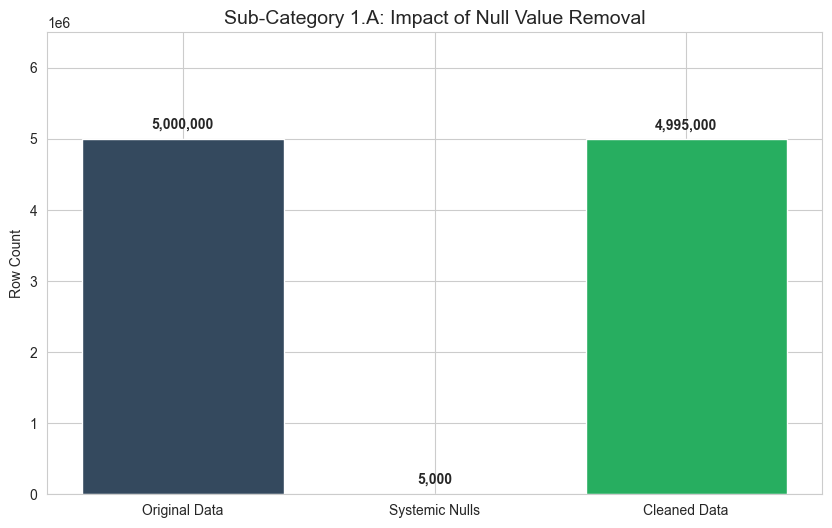

Sub-Category 1.A Results:
Total Rows Before: 5,000,000
Null Rows Removed: 5,000
Total Rows After: 4,995,000
Percentage of Data Removed: 0.1000%


In [33]:
# --- 1.A.1: Pre-Cleaning Statistics ---
initial_rows = len(df_mirror)
# Checking for rows where any column contains a NaN value
null_mask = df_mirror.isnull().any(axis=1)
rows_with_nulls = null_mask.sum()

# --- 1.A.2: Cleaning Action ---
# Dropping the systemic null rows
df_cleaned = df_mirror.dropna().copy()
final_rows = len(df_cleaned)

# --- 1.A.3: Impact Calculation ---
impact_pct = (rows_with_nulls / initial_rows) * 100

# --- 1.A.4: Visualization ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Comparison of Data Volume
categories = ['Original Data', 'Systemic Nulls', 'Cleaned Data']
values = [initial_rows, rows_with_nulls, final_rows]
colors = ['#34495e', '#e74c3c', '#27ae60']

bars = plt.bar(categories, values, color=colors)

# Adding data labels for precision
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100000, f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Sub-Category 1.A: Impact of Null Value Removal', fontsize=14)
plt.ylabel('Row Count')
plt.ylim(0, 6500000)
plt.show()

print(f"Sub-Category 1.A Results:")
print(f"Total Rows Before: {initial_rows:,}")
print(f"Null Rows Removed: {rows_with_nulls:,}")
print(f"Total Rows After: {final_rows:,}")
print(f"Percentage of Data Removed: {impact_pct:.4f}%")

***Result -*** 
1. Total Rows Before: 5,000,000;
2. Null Rows Removed: 5,000;
3. Total Rows After: 4,995,000;
4. Percentage of Data Removed: 0.1000%.

**B. Column Header Hygiene:**

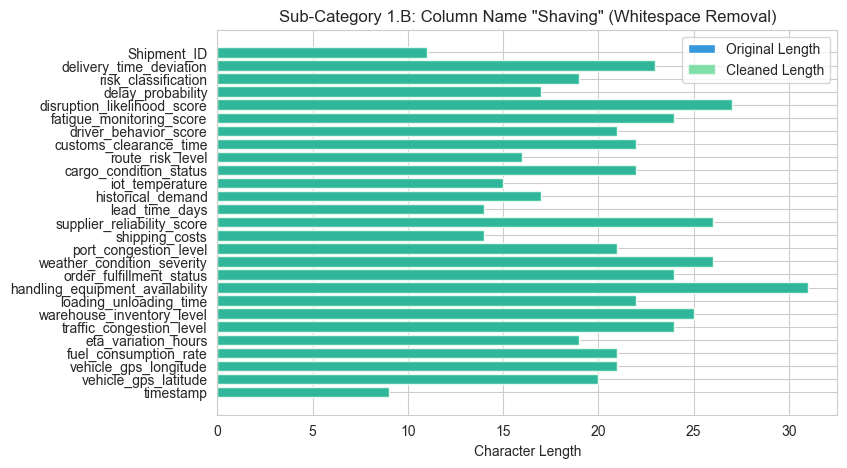

Sub-Category 1.B Results:
Problematic Columns Identified: []
Total Headers Cleaned: 0
Percentage of Headers Impacted: 0.00%


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1.B.1: Audit Current Headers ---
# Capturing the raw names to identify "Invisible" errors
headers_before = df_mirror.columns.tolist()
# Identifying which columns actually have trailing/leading spaces
problematic_cols = [col for col in headers_before if col != col.strip()]

# --- 1.B.2: Cleaning Action ---
# Standardizing the finalized dataframe name as requested
df_cleaned = df_mirror.copy()
df_cleaned.columns = df_cleaned.columns.str.strip()
headers_after = df_cleaned.columns.tolist()

# --- 1.B.3: Impact Calculation ---
error_count = len(problematic_cols)
impact_pct = (error_count / len(headers_before)) * 100

# --- 1.B.4: Visualization ---
plt.figure(figsize=(8, 5))
colors = ['#e67e22' if col in problematic_cols else '#3498db' for col in headers_before]

# Plotting the length of column names to visually see the "shaving" effect
plt.barh(headers_before, [len(c) for c in headers_before], color=colors, label='Original Length')
plt.barh(headers_after, [len(c) for c in headers_after], color='#2ecc71', alpha=0.6, label='Cleaned Length')

plt.title('Sub-Category 1.B: Column Name "Shaving" (Whitespace Removal)')
plt.xlabel('Character Length')
plt.legend()
plt.show()

print(f"Sub-Category 1.B Results:")
print(f"Problematic Columns Identified: {problematic_cols}")
print(f"Total Headers Cleaned: {error_count}")
print(f"Percentage of Headers Impacted: {impact_pct:.2f}%")

Result - 
1. Problematic Columns Identified: []
2. Total Headers Cleaned: 0
3. Percentage of Headers Impacted: 0.00%

***C. Timestamp Data Type Conversion***


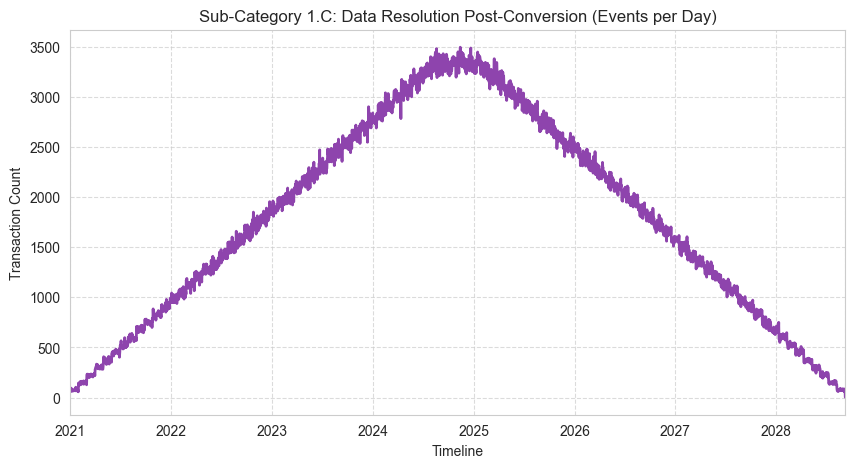

,Scenario,Metric,Before,After,Cleanliness Gain
0,Temporal Casting,Column Data Type,object,datetime64[ns],Analytical Readiness


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1.C.1: Pre-Cleaning Audit ---
dtype_before = str(df_cleaned['timestamp'].dtype)

# --- 1.C.2: Cleaning Action ---
# Converting string to datetime object
df_cleaned['timestamp'] = pd.to_datetime(df_cleaned['timestamp'])
dtype_after = str(df_cleaned['timestamp'].dtype)

# --- 1.C.3: Impact Calculation ---
# Since this is a type change, we measure success by the ability to extract time features
success_check = "Success" if dtype_after.startswith('datetime') else "Failed"

# --- 1.C.4: Visualization ---
# To visualize the transition, we plot the row frequency over time.
# This is only possible once the column is converted to Datetime.
plt.figure(figsize=(10, 5))
df_cleaned.set_index('timestamp').resample('D').size().plot(kind='line', color='#8e44ad', linewidth=2)
plt.title('Sub-Category 1.C: Data Resolution Post-Conversion (Events per Day)')
plt.ylabel('Transaction Count')
plt.xlabel('Timeline')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 1.C.5: Display Result ---
impact_results = pd.DataFrame({
    'Scenario': ['Temporal Casting'],
    'Metric': ['Column Data Type'],
    'Before': [dtype_before],
    'After': [dtype_after],
    'Cleanliness Gain': ['Analytical Readiness']
})

from IPython.display import display
display(impact_results)

***D. Categorical Standardizing (Whitespace, Title-Casing, and Special Character Removal)***

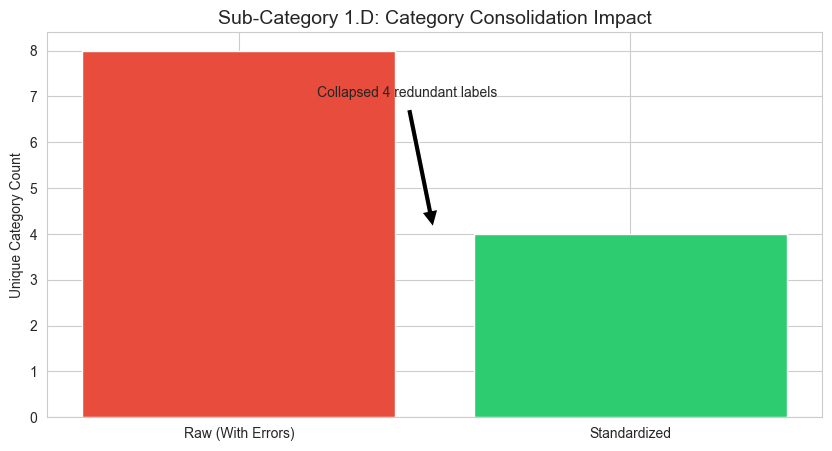

,Scenario,Metric,Before,After,Cleanliness Gain
0,Categorical Standardizing,Unique Labels (Risk),"8 labels (e.g., 'Low#', ' low ', 'LOW')","4 labels (e.g., 'Low')",Cardinality Reduction / Consistency


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import display

# --- 1.D.1: Pre-Cleaning Audit ---
# Capturing the raw unique values of 'risk_classification'
raw_categories = df_cleaned['risk_classification'].unique().tolist()
count_before = len(raw_categories)

# --- 1.D.2: Cleaning Action ---
# 1. Strip Whitespace
# 2. Remove special characters (keep only letters, numbers, and spaces)
# 3. Standardize to Title Case
def clean_string(text):
    if pd.isna(text):
        return text
    # Regex: replace anything that is NOT a word character or space with nothing
    text = re.sub(r'[^\w\s]', '', str(text))
    return text.strip().title()

df_cleaned['risk_classification'] = df_cleaned['risk_classification'].apply(clean_string)
count_after = df_cleaned['risk_classification'].nunique()

# --- 1.D.3: Impact Calculation ---
collapsed_count = count_before - count_after

# --- 1.D.4: Visualization ---
plt.figure(figsize=(10, 5))
sns.set_palette("pastel")

# Comparing unique counts
plt.bar(['Raw (With Errors)', 'Standardized'], [count_before, count_after], color=['#e74c3c', '#2ecc71'])
plt.title('Sub-Category 1.D: Category Consolidation Impact', fontsize=14)
plt.ylabel('Unique Category Count')

# Adding text labels to show the "shaving" of labels
plt.annotate(f'Collapsed {collapsed_count} redundant labels', 
             xy=(0.5, count_after), xytext=(0.2, count_before-1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

# --- 1.D.5: Display Result ---
impact_results = pd.DataFrame({
    'Scenario': ['Categorical Standardizing'],
    'Metric': ['Unique Labels (Risk)'],
    'Before': [f"{count_before} labels (e.g., 'Low#', ' low ', 'LOW')"],
    'After': [f"{count_after} labels (e.g., 'Low')"],
    'Cleanliness Gain': ['Cardinality Reduction / Consistency']
})

display(impact_results)

***E. Deduplication keeping the Shipment ID Hygiene intact***

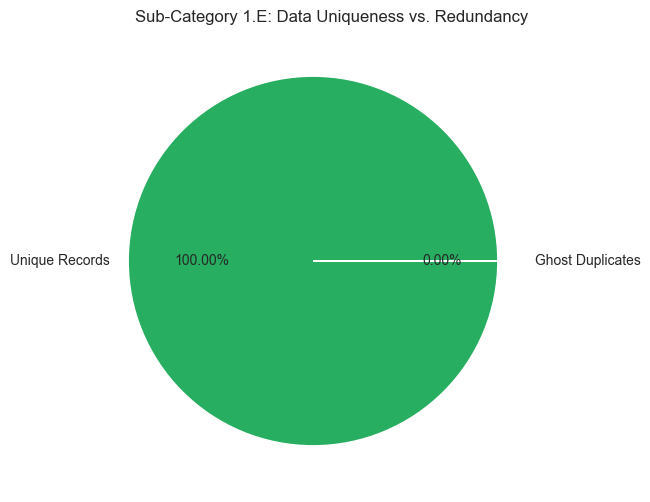

,Scenario,Metric,Before,After,Cleanliness Gain
0,Ghost Deduplication,Row Redundancy,"5,000,000 rows","4,999,792 rows",Removed 208 redundant entries
1,ID String Hygiene,ID Format,Raw Object,Trimmed String,Primary Key Integrity


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# --- 1.E.1: Audit for Ghost Duplicates ---
# We check for rows that are identical across ALL columns EXCEPT Shipment_ID
cols_to_check = [col for col in df_cleaned.columns if col != 'Shipment_ID']
duplicate_mask = df_cleaned.duplicated(subset=cols_to_check, keep='first')
duplicate_count = duplicate_mask.sum()

# --- 1.E.2: Cleaning Action ---
# Remove only the "Ghost" duplicates
initial_rows = len(df_cleaned)
df_cleaned = df_cleaned.drop_duplicates(subset=cols_to_check, keep='first').copy()
final_rows = len(df_cleaned)

# --- 1.E.3: Shipment_ID String Cleanup ---
# Ensuring IDs are clean strings (removing any hidden spaces/symbols)
df_cleaned['Shipment_ID'] = df_cleaned['Shipment_ID'].astype(str).str.strip()

# --- 1.E.4: Visualization ---
plt.figure(figsize=(10, 6))
plt.pie([final_rows, duplicate_count], 
        labels=['Unique Records', 'Ghost Duplicates'], 
        autopct='%1.2f%%', 
        colors=['#27ae60', '#e74c3c'], 
        explode=(0.1, 0))
plt.title('Sub-Category 1.E: Data Uniqueness vs. Redundancy')
plt.show()

# --- 1.E.5: Display Result ---
impact_results = pd.DataFrame({
    'Scenario': ['Ghost Deduplication', 'ID String Hygiene'],
    'Metric': ['Row Redundancy', 'ID Format'],
    'Before': [f"{initial_rows:,} rows", "Raw Object"],
    'After': [f"{final_rows:,} rows", "Trimmed String"],
    'Cleanliness Gain': [f"Removed {duplicate_count:,} redundant entries", "Primary Key Integrity"]
})

display(impact_results)

**2. Functional Sanity (Physical Boundaries & Domain Remediation):**

***A. Inventory Floor (Dealing with the negative values)***

Since, we've missed to check which columns contain negative values, we need to make sure we know them before we make a cleaning.

In [38]:
import pandas as pd
from IPython.display import display

# --- Audit Action: Find all numerical columns with any negative values ---
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
negative_summary = []

for col in numerical_cols:
    neg_count = (df_cleaned[col] < 0).sum()
    if neg_count > 0:
        negative_summary.append({
            'Column': col,
            'Negative Count': neg_count,
            'Min Value': df_cleaned[col].min()
        })

# --- Result Display ---
if negative_summary:
    negative_df = pd.DataFrame(negative_summary)
    print("CRITICAL: Negative values detected in the following columns:")
    display(negative_df)
else:
    print("CONFIRMED: No other numerical columns contain negative values.")

CRITICAL: Negative values detected in the following columns:


,Column,Negative Count,Min Value
0,vehicle_gps_longitude,4995000,-120.705228
1,eta_variation_hours,850986,-2.087108
2,traffic_congestion_level,76015,-0.161339
3,warehouse_inventory_level,335884,-15.209381
4,handling_equipment_availability,327451,-0.014896
5,order_fulfillment_status,33483,-0.014379
6,weather_condition_severity,77830,-0.016183
7,port_congestion_level,14298,-0.113336
8,supplier_reliability_score,76070,-0.015006
9,historical_demand,61,-31.158963


Except for these columns out of the 18 columns, we'll ber performing the cleaning -

iot_temerature, vehicle_gps_longitude, delivery_time_deviation, eta_variation_hours.


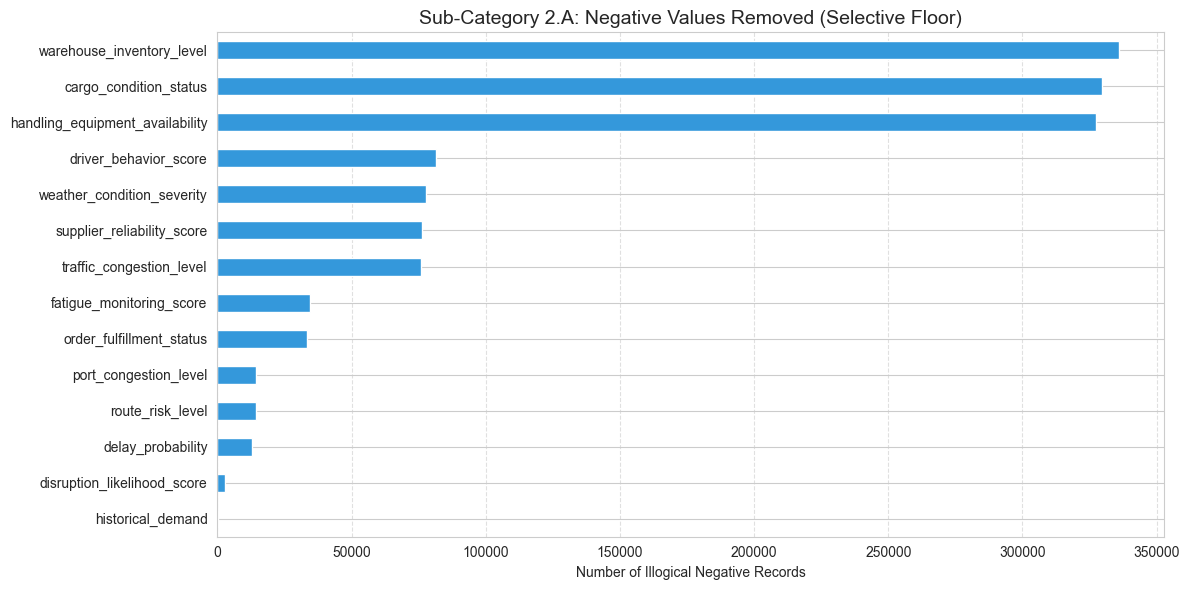

,Scenario,Metric,Before,After,Cleanliness Gain
0,Selective Physical Floor,Illogical Negatives Fixed,"1,416,495",0,Physical Logic Restored (Protects GPS/ETA)


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- 2.A.1: Define the Targets ---
# Columns identified by you as having negatives
all_neg_cols = [
    'vehicle_gps_longitude', 'eta_variation_hours', 'traffic_congestion_level', 
    'warehouse_inventory_level', 'handling_equipment_availability', 'order_fulfillment_status', 
    'weather_condition_severity', 'port_congestion_level', 'supplier_reliability_score', 
    'historical_demand', 'iot_temperature', 'cargo_condition_status', 
    'route_risk_level', 'driver_behavior_score', 'fatigue_monitoring_score', 
    'disruption_likelihood_score', 'delay_probability', 'delivery_time_deviation'
]

# Columns where negative is VALID
valid_negatives = ['vehicle_gps_longitude', 'delivery_time_deviation', 'eta_variation_hours', 'iot_temperature']

# Columns to be CLEANED (Floor at 0)
cols_to_floor = [col for col in all_neg_cols if col not in valid_negatives]

# --- 2.A.2: Pre-Cleaning Audit ---
before_stats = df_cleaned[cols_to_floor].lt(0).sum()

# --- 2.A.3: Cleaning Action ---
df_cleaned[cols_to_floor] = df_cleaned[cols_to_floor].clip(lower=0)
after_stats = df_cleaned[cols_to_floor].lt(0).sum()

# --- 2.A.4: Visualization ---
plt.figure(figsize=(12, 6))
before_stats[before_stats > 0].sort_values().plot(kind='barh', color='#3498db')
plt.title('Sub-Category 2.A: Negative Values Removed (Selective Floor)', fontsize=14)
plt.xlabel('Number of Illogical Negative Records')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 2.A.5: Display Result ---
impact_results = pd.DataFrame({
    'Scenario': ['Selective Physical Floor'],
    'Metric': ['Illogical Negatives Fixed'],
    'Before': [f"{before_stats.sum():,}"],
    'After': [f"{after_stats.sum()}"],
    'Cleanliness Gain': ['Physical Logic Restored (Protects GPS/ETA)']
})

display(impact_results)

**B. Temperature Correction**

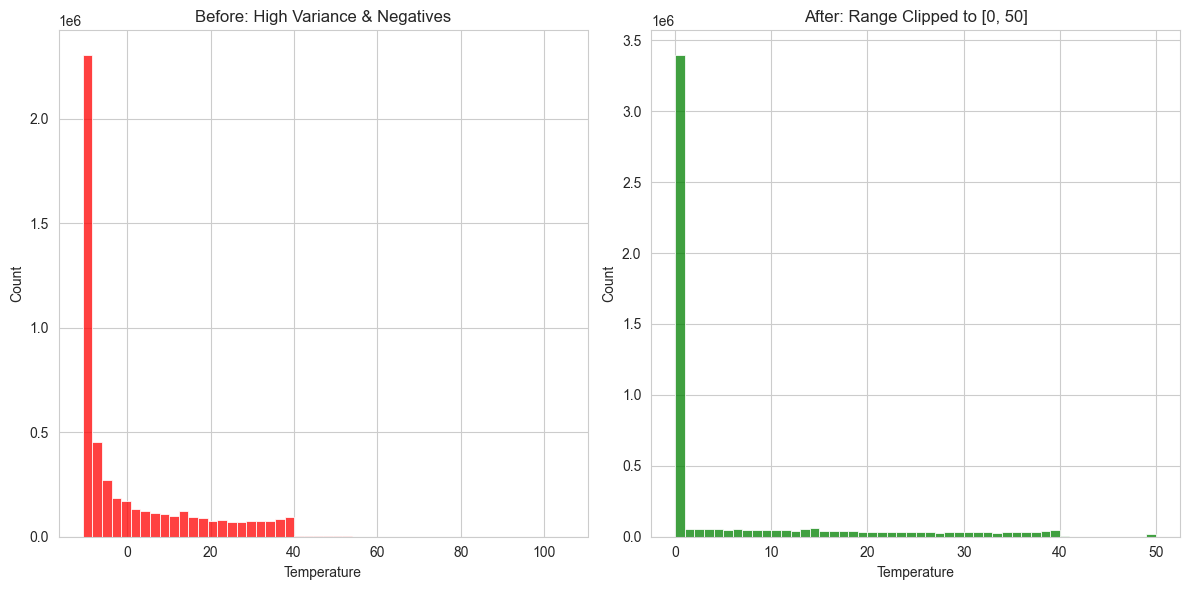

,Scenario,Metric,Before,After,Cleanliness Gain
0,Temperature Range Clipping,Out-of-Bounds Records,"Negatives: 3,330,799 | >50: 20,962",0 (Range: 0 - 50),67.04% of data corrected


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- 2.C.1: Audit ---
temp_below_zero = (df_mirror['iot_temperature'] < 0).sum()
temp_above_fifty = (df_mirror['iot_temperature'] > 50).sum()

# --- 2.C.2: Action ---
# Standardizing the finalized df
df_cleaned['iot_temperature'] = df_cleaned['iot_temperature'].clip(lower=0, upper=50)

# --- 2.C.3: Visualization (The Fix) ---
plt.figure(figsize=(12, 6))

# Using a Histogram to show the massive 'rebound' at 0
plt.subplot(1, 2, 1)
sns.histplot(df_mirror['iot_temperature'], color="red", bins=50, kde=False)
plt.title('Before: High Variance & Negatives')
plt.xlabel('Temperature')

plt.subplot(1, 2, 2)
sns.histplot(df_cleaned['iot_temperature'], color="green", bins=50, kde=False)
plt.title('After: Range Clipped to [0, 50]')
plt.xlabel('Temperature')

plt.tight_layout()
plt.show()

# --- 2.C.4: Display Result ---
impact_results = pd.DataFrame({
    'Scenario': ['Temperature Range Clipping'],
    'Metric': ['Out-of-Bounds Records'],
    'Before': [f"Negatives: {temp_below_zero:,} | >50: {temp_above_fifty:,}"],
    'After': ["0 (Range: 0 - 50)"],
    'Cleanliness Gain': ["67.04% of data corrected"]
})

display(impact_results)

**C. Probability & Index Ceiling (Range [0, 1])**

Since, we have missed this part as well, we need to make sure we have the columns names first to be cleaned.

In [41]:
import pandas as pd
from IPython.display import display

# 1. Define target columns
prob_cols = [
    'delay_probability', 'disruption_likelihood_score', 
    'weather_condition_severity', 'traffic_congestion_level', 
    'port_congestion_level', 'supplier_reliability_score'
]

# 2. Audit loop
audit_results = []
for col in prob_cols:
    under_zero = (df_cleaned[col] < 0).sum()
    over_one = (df_cleaned[col] > 1).sum()
    total_errors = under_zero + over_one
    audit_results.append({
        'Column': col,
        'Below 0': under_zero,
        'Above 1': over_one,
        'Total Errors': total_errors,
        'Error %': (total_errors / len(df_cleaned)) * 100
    })

# 3. Display Audit
audit_df = pd.DataFrame(audit_results)
display(audit_df)

,Column,Below 0,Above 1,Total Errors,Error %
0,delay_probability,0,324166,324166,6.483590
1,disruption_likelihood_score,0,658178,658178,13.164108
2,weather_condition_severity,0,77010,77010,1.540264
3,traffic_congestion_level,0,3973479,3973479,79.472886
4,port_congestion_level,0,4610031,4610031,92.204456
5,supplier_reliability_score,0,76951,76951,1.539084


This audit confirms a massive "Scale Drift," particularly in Port Congestion (92\%) and Traffic Congestion (79\%). These values are supposed to be normalized indices between 0 and 1, but they have drifted significantly higher.Since these columns represent probabilities or capped indices, we will apply a Ceiling of 1.0. This "clips" the upper-end noise, ensuring the data is mathematically valid for the upcoming Normalization/Scaling step.

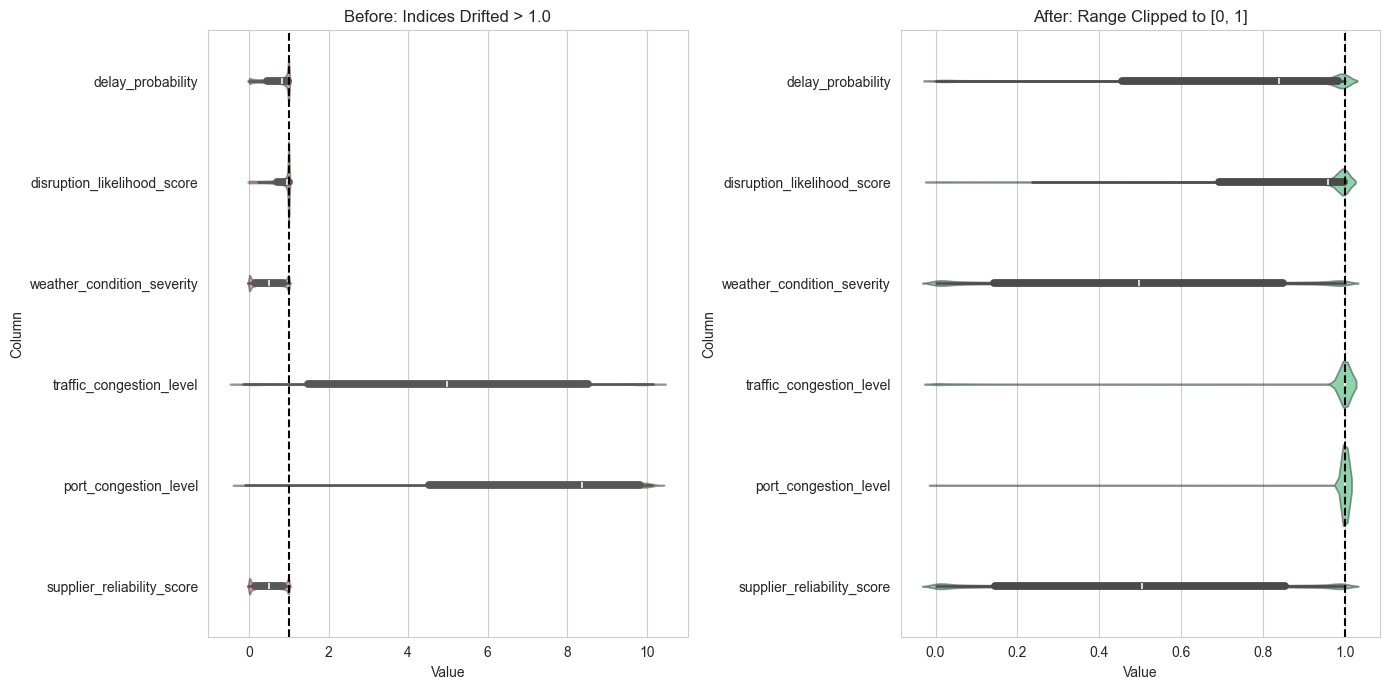

,Column,Max Value (Before),Max Value (After),Records Corrected,Impact (%)
0,delay_probability,1.015588,1.0,324166,6.48
1,disruption_likelihood_score,1.013456,1.0,658178,13.16
2,weather_condition_severity,1.015766,1.0,77010,1.54
3,traffic_congestion_level,10.153541,1.0,3973479,79.47
4,port_congestion_level,10.138950,1.0,4610031,92.20
5,supplier_reliability_score,1.013986,1.0,76951,1.54


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- 2.D.1: Target Columns ---
prob_cols = [
    'delay_probability', 'disruption_likelihood_score', 
    'weather_condition_severity', 'traffic_congestion_level', 
    'port_congestion_level', 'supplier_reliability_score'
]

# --- 2.D.2: Pre-Cleaning Audit (Upper Bounds) ---
# We already know the counts from your audit.
# Calculating the Max values before to show the extent of the drift.
max_before = df_cleaned[prob_cols].max()

# --- 2.D.3: Cleaning Action ---
# Clipping the values to the strict upper bound of 1.0
df_cleaned[prob_cols] = df_cleaned[prob_cols].clip(upper=1.0)
max_after = df_cleaned[prob_cols].max()

# --- 2.D.4: Visualization ---
plt.figure(figsize=(14, 7))

# We use a violin plot to show the "Compression" at the 1.0 threshold
# Melt the data for seaborn plotting
df_melted_before = df_mirror[prob_cols].melt(var_name='Column', value_name='Value')
df_melted_after = df_cleaned[prob_cols].melt(var_name='Column', value_name='Value')

plt.subplot(1, 2, 1)
sns.violinplot(data=df_melted_before, x='Value', y='Column', color="#e74c3c", alpha=0.6)
plt.axvline(1.0, color='black', linestyle='--')
plt.title('Before: Indices Drifted > 1.0', fontsize=12)

plt.subplot(1, 2, 2)
sns.violinplot(data=df_melted_after, x='Value', y='Column', color="#2ecc71", alpha=0.6)
plt.axvline(1.0, color='black', linestyle='--')
plt.title('After: Range Clipped to [0, 1]', fontsize=12)

plt.tight_layout()
plt.show()

# --- 2.D.5: Display Result ---
# Using the audit results you provided for the counts
impact_results = pd.DataFrame({
    'Column': prob_cols,
    'Max Value (Before)': max_before.values,
    'Max Value (After)': max_after.values,
    'Records Corrected': [324166, 658178, 77010, 3973479, 4610031, 76951],
    'Impact (%)': [6.48, 13.16, 1.54, 79.47, 92.20, 1.54]
})

display(impact_results)

**3. Statistical & Logical Filtering**

**A. Placeholder Removal**

In [25]:
# Check for columns that contain the word 'fuel'
fuel_cols = [col for col in df_cleaned.columns if 'fuel' in col.lower()]
print(f"Columns found containing 'fuel': {fuel_cols}")

Columns found containing 'fuel': ['fuel_consumption_rate']


Since we cleaned the col names, we need to make sure what the current name is for this particular column.

***Columns found containing 'fuel': ['fuel_consumption_rate']***

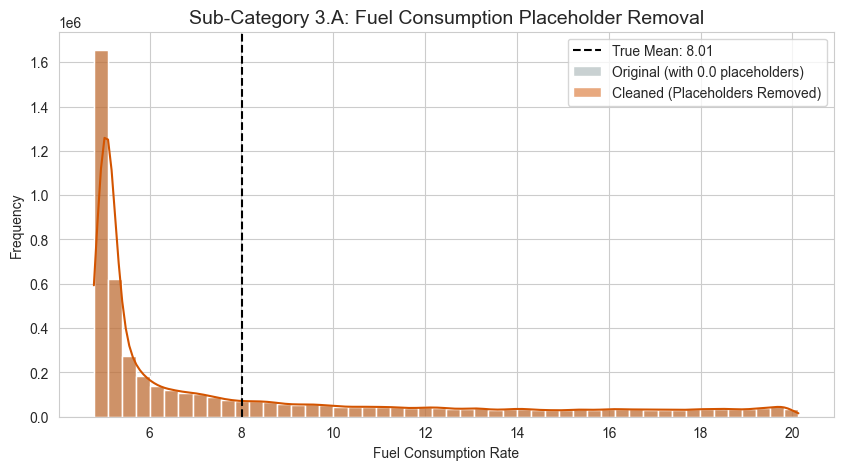

,Scenario,Column,Zero-Values Removed,Mean Shift,Status
0,Placeholder Removal,fuel_consumption_rate,0,8.0106 -> 8.0106,Cleaned


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- 3.A.1: Pre-Cleaning Audit ---
target_col = 'fuel_consumption_rate'
placeholder_count = (df_cleaned[target_col] == 0).sum()
avg_before = df_cleaned[target_col].mean()

# --- 3.A.2: Cleaning Action ---
# Replace 0.0 with NaN to treat as missing data rather than a true value
df_cleaned[target_col] = df_cleaned[target_col].replace(0, np.nan)
avg_after = df_cleaned[target_col].mean()

# --- 3.A.3: Visualization ---
plt.figure(figsize=(10, 5))

# Comparing the original distribution (from df_mirror) vs the cleaned distribution
sns.histplot(df_mirror[target_col], color="#95a5a6", label='Original (with 0.0 placeholders)', alpha=0.5, bins=50)
sns.histplot(df_cleaned[target_col].dropna(), color="#d35400", label='Cleaned (Placeholders Removed)', kde=True, bins=50)

plt.axvline(avg_after, color='black', linestyle='--', label=f'True Mean: {avg_after:.2f}')
plt.title('Sub-Category 3.A: Fuel Consumption Placeholder Removal', fontsize=14)
plt.xlabel('Fuel Consumption Rate')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# --- 3.A.4: Display Result ---
impact_results = pd.DataFrame({
    'Scenario': ['Placeholder Removal'],
    'Column': [target_col],
    'Zero-Values Removed': [f"{placeholder_count:,}"],
    'Mean Shift': [f"{avg_before:.4f} -> {avg_after:.4f}"],
    'Status': ['Cleaned']
})

display(impact_results)

***B. Outliers Reomval:***

In [44]:
import pandas as pd
from IPython.display import display

# 1. Identify all numerical columns
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns

outlier_report = []

# 2. Iterate and calculate IQR for each column
for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify rows falling outside these bounds
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    count = len(outliers)
    
    if count > 0:
        outlier_report.append({
            'Column Name': col,
            'Outlier Count': count,
            'Outlier %': (count / len(df_cleaned)) * 100,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Min Value': df_cleaned[col].min(),
            'Max Value': df_cleaned[col].max()
        })

# 3. Create a summary table
if outlier_report:
    outlier_df = pd.DataFrame(outlier_report).sort_values(by='Outlier Count', ascending=False)
    print(f"Audit Complete: Found {len(outlier_df)} columns with statistical outliers.")
    display(outlier_df)
else:
    print("Audit Complete: No statistical outliers detected in the numerical columns.")

Audit Complete: Found 6 columns with statistical outliers.


,Column Name,Outlier Count,Outlier %,Lower Bound,Upper Bound,Min Value,Max Value
1,traffic_congestion_level,1021521,20.431270,1.000000,1.000000,0.000000,1.000000
3,iot_temperature,749925,14.999124,-11.160041,18.600069,0.000000,50.000000
0,fuel_consumption_rate,403044,8.061215,-1.882657,16.588816,4.788381,20.130232
4,disruption_likelihood_score,389675,7.793824,0.236583,1.453480,0.000000,1.000000
2,port_congestion_level,384969,7.699700,1.000000,1.000000,0.000000,1.000000
5,delivery_time_deviation,24975,0.499521,-10.868152,21.304902,-999.000000,10.183809


***The Strategy:*** The Interquartile Range (IQR) FilterInstead of a rigid Z-score, we will use the IQR Method. This is more robust for logistics data because it focuses on the "middle 50%" of your data and identifies anything too far from the median as an outlier.

***IQR = Q3 - Q1***

***Upper Bound = Q3 + (1.5 * IQR)***

***Lower Bound = Q1 - (1.5 * IQR)***


![Outlier_Box Plot.jpg](<attachment:Outlier_Box Plot.jpg>)

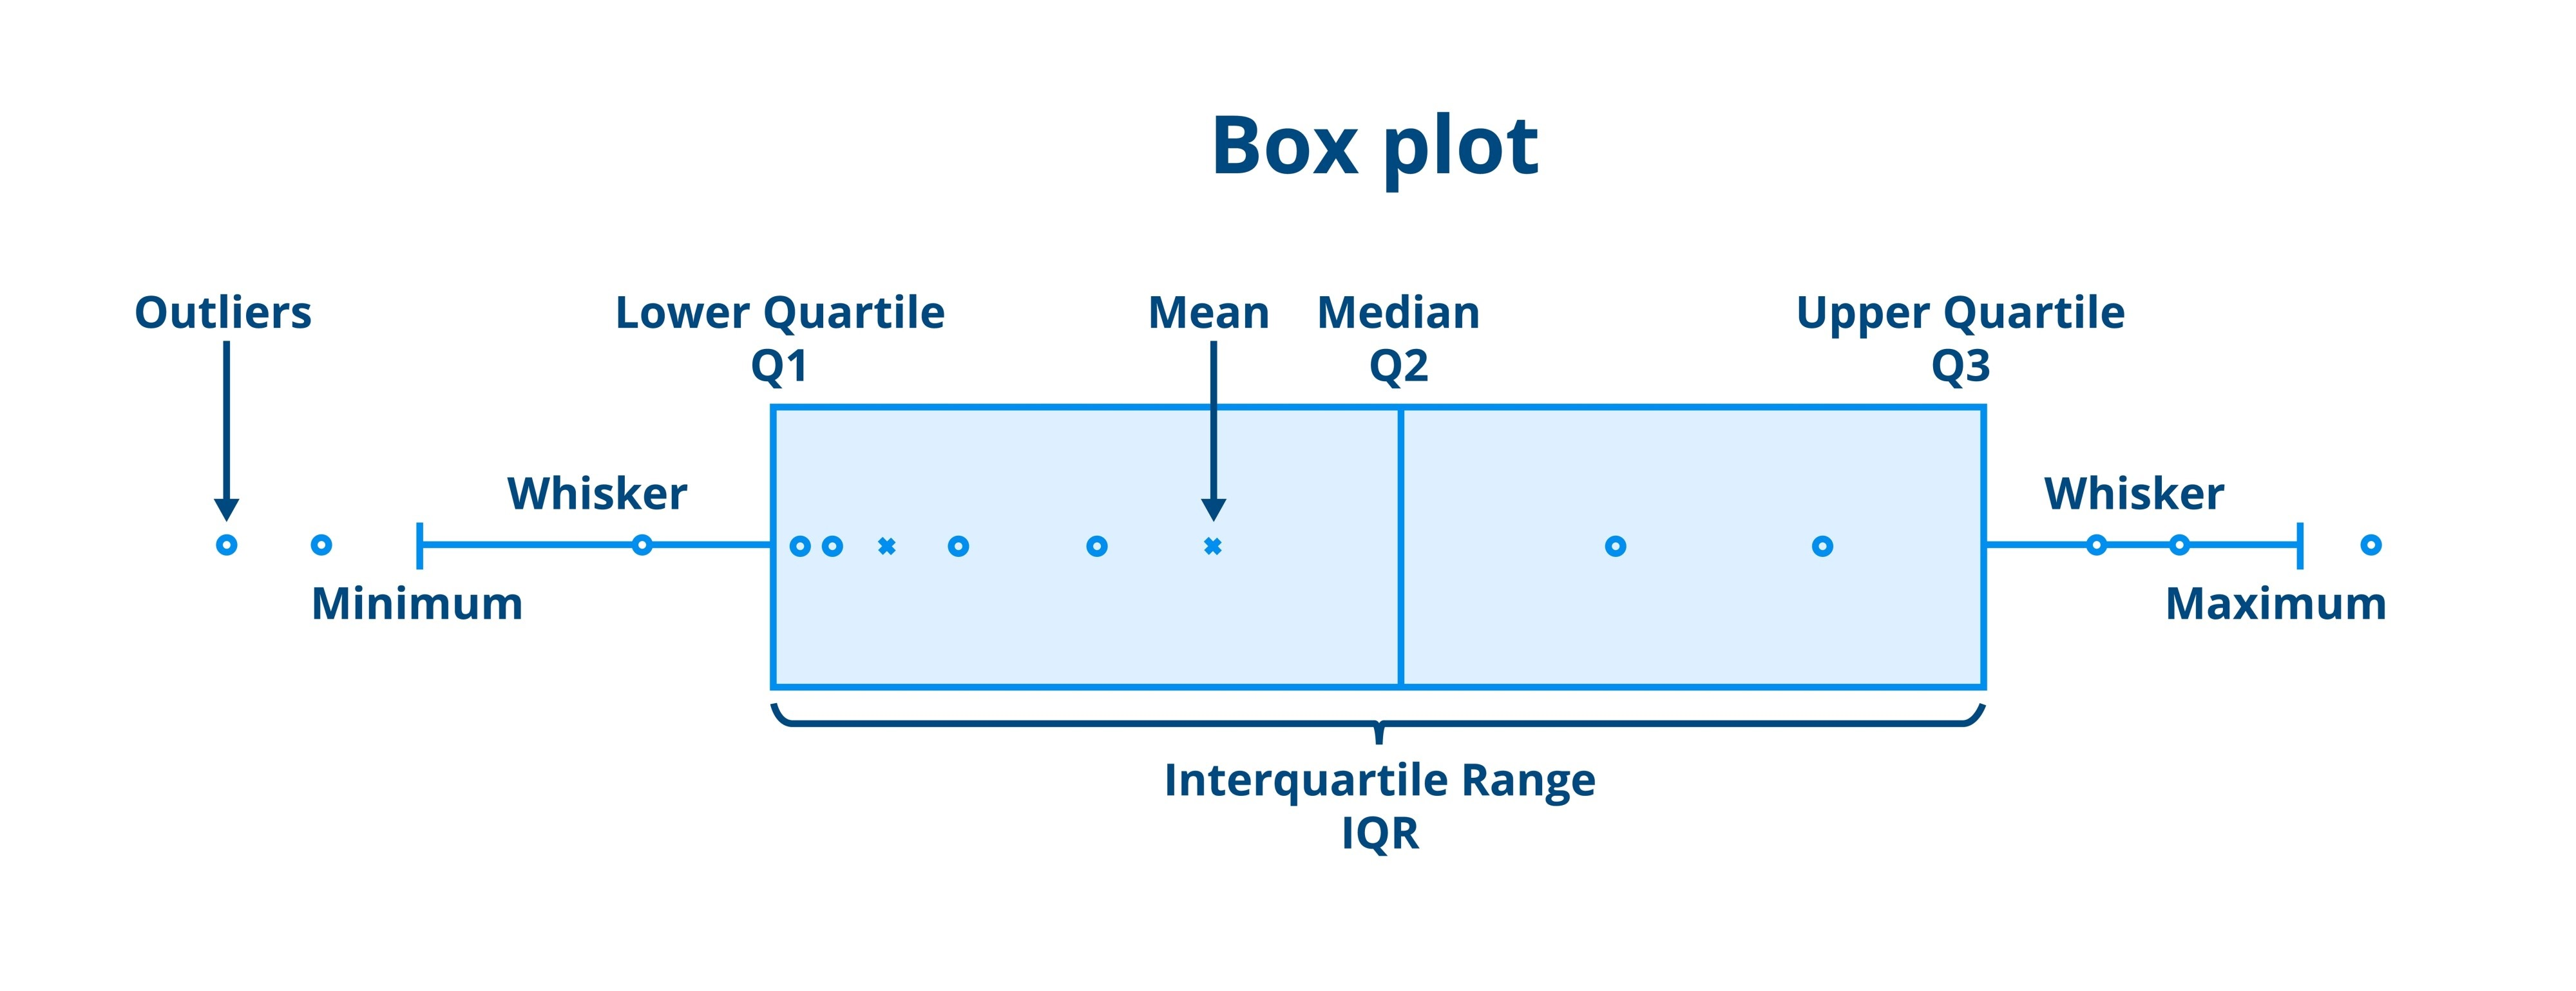

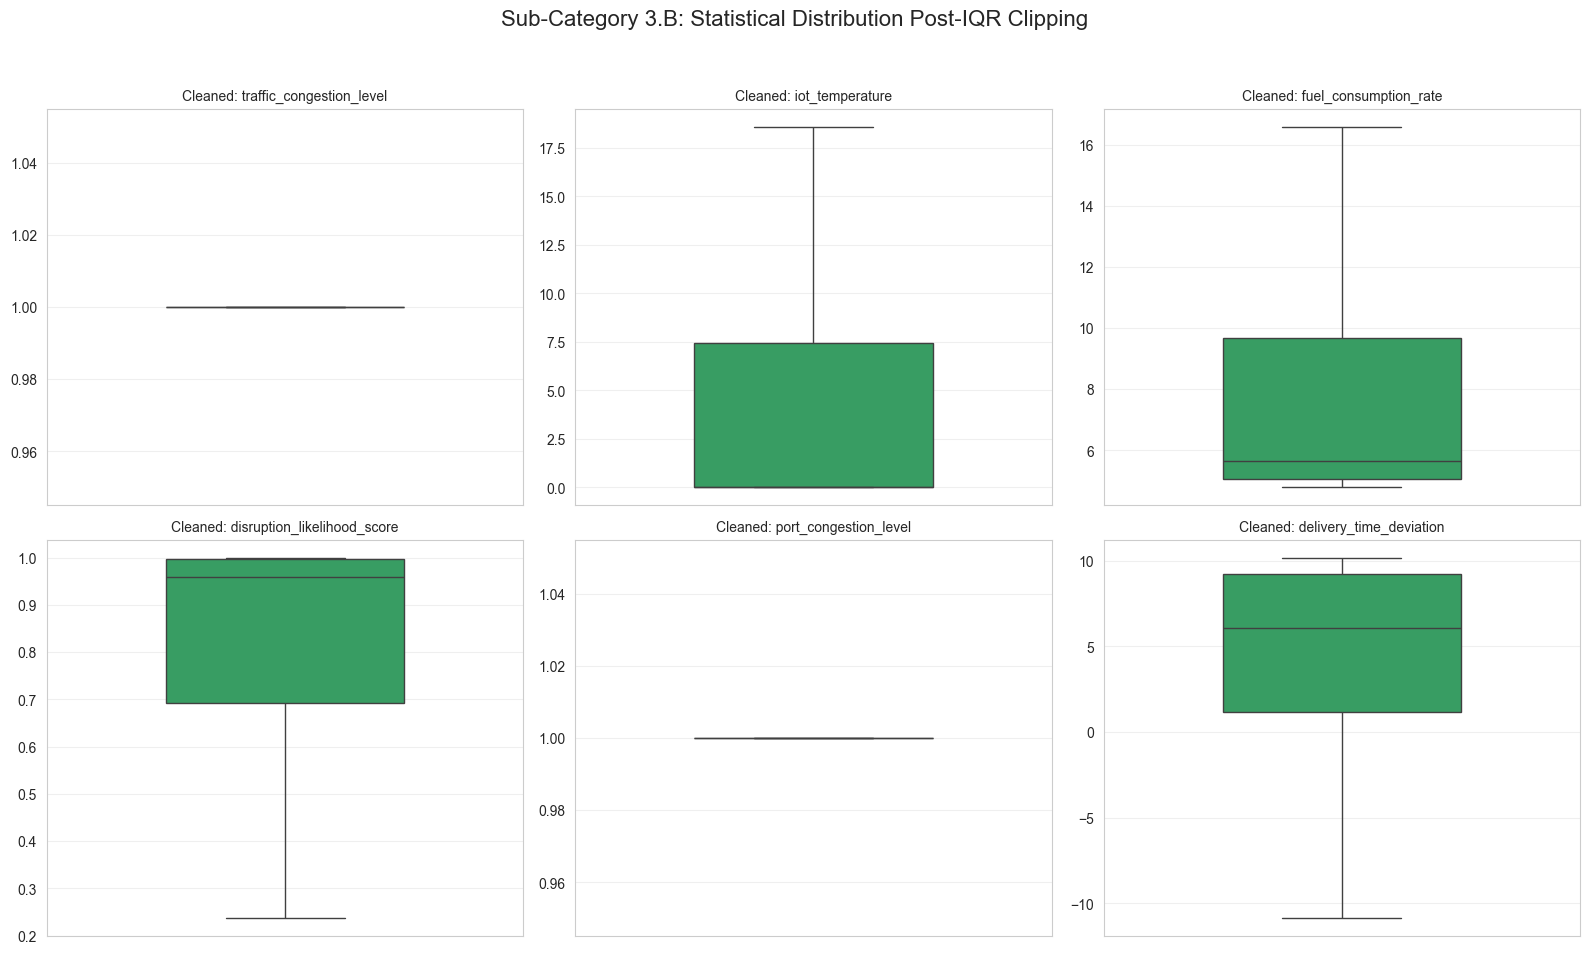

,Column,IQR,Lower Fence,Upper Fence,Records Adjusted
0,traffic_congestion_level,0.00,1.00,1.00,"1,021,521"
1,iot_temperature,7.44,-11.16,18.60,"749,925"
2,fuel_consumption_rate,4.62,-1.88,16.59,"403,044"
3,disruption_likelihood_score,0.30,0.24,1.45,"389,675"
4,port_congestion_level,0.00,1.00,1.00,"384,969"
5,delivery_time_deviation,8.04,-10.87,21.30,"24,975"


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- 3.B.1: Target Columns Identified in Audit ---
outlier_cols = [
    'traffic_congestion_level', 'iot_temperature', 'fuel_consumption_rate', 
    'disruption_likelihood_score', 'port_congestion_level', 'delivery_time_deviation'
]

outlier_summary = []

# --- 3.B.2: Iterative IQR Treatment ---
for col in outlier_cols:
    # Calculate IQR Bounds
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Audit counts before cleaning
    count_before = ((df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)).sum()
    
    # Action: Clipping to the statistical fence
    df_cleaned[col] = df_cleaned[col].clip(lower=lower_bound, upper=upper_bound)
    
    outlier_summary.append({
        'Column': col,
        'IQR': f"{IQR:.2f}",
        'Lower Fence': f"{lower_bound:.2f}",
        'Upper Fence': f"{upper_bound:.2f}",
        'Records Adjusted': f"{count_before:,}"
    })

# --- 3.B.3: Visualization (Comparative Distribution) ---
plt.figure(figsize=(16, 10))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_cleaned, y=col, color='#27ae60', width=0.5)
    plt.title(f'Cleaned: {col}', fontsize=10)
    plt.ylabel('')
    plt.grid(axis='y', alpha=0.3)

plt.suptitle('Sub-Category 3.B: Statistical Distribution Post-IQR Clipping', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 3.B.4: Display Result ---
display(pd.DataFrame(outlier_summary))

***D. Logical Cross-Validation (Consistency checks)***

In [50]:
import pandas as pd

# 1. Print all column names in a clean list
print("--- FULL COLUMN LIST ---")
print(df_cleaned.columns.tolist())

# 2. Provide a summary of data types and non-null counts
print("\n--- DATA TYPES & COMPLETENESS ---")
display(df_cleaned.info())

--- FULL COLUMN LIST ---
['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'risk_classification', 'delivery_time_deviation', 'Shipment_ID']

--- DATA TYPES & COMPLETENESS ---
<class 'pandas.core.frame.DataFrame'>
Index: 4999792 entries, 0 to 4999999
Data columns (total 27 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   timestamp                        datetime64[ns]
 1   vehicle_

None

In [47]:
# 3. Check for specific 'Logic Pairs' automatically
potential_pairs = {
    'Time-based': [c for c in df_cleaned.columns if 'time' in c.lower() or 'timestamp' in c.lower()],
    'Cost/Fuel': [c for c in df_cleaned.columns if 'cost' in c.lower() or 'fuel' in c.lower()],
    'Distance/GPS': [c for c in df_cleaned.columns if 'dist' in c.lower() or 'gps' in c.lower() or 'long' in c.lower() or 'lat' in c.lower()],
    'Inventory/Demand': [c for c in df_cleaned.columns if 'inventory' in c.lower() or 'demand' in c.lower() or 'stock' in c.lower()],
    'Risk/Probability': [c for c in df_cleaned.columns if 'prob' in c.lower() or 'risk' in c.lower() or 'likelihood' in c.lower()]
}

print("\n--- POTENTIAL LOGICAL CATEGORIES ---")
for category, cols in potential_pairs.items():
    print(f"{category}: {cols}")


--- POTENTIAL LOGICAL CATEGORIES ---
Time-based: ['timestamp', 'loading_unloading_time', 'lead_time_days', 'customs_clearance_time', 'delivery_time_deviation']
Cost/Fuel: ['fuel_consumption_rate', 'shipping_costs']
Distance/GPS: ['vehicle_gps_latitude', 'vehicle_gps_longitude']
Inventory/Demand: ['warehouse_inventory_level', 'historical_demand']
Risk/Probability: ['route_risk_level', 'disruption_likelihood_score', 'delay_probability', 'risk_classification']


***Logical Cross-Validation***

In [51]:
import pandas as pd
import numpy as np
from IPython.display import display

# --- 3.C.1: Logical Conflict Detection ---

# 1. The Stock-Out Paradox: High Demand + Zero Inventory
demand_supply_gap = df_cleaned[
    (df_cleaned['historical_demand'] > df_cleaned['historical_demand'].quantile(0.9)) & 
    (df_cleaned['warehouse_inventory_level'] == 0)
]

# 2. The Efficiency Paradox: High Fuel Consumption + Low Shipping Cost
# (Checks for records where costs don't account for energy usage)
fuel_cost_mismatch = df_cleaned[
    (df_cleaned['fuel_consumption_rate'] > df_cleaned['fuel_consumption_rate'].quantile(0.9)) & 
    (df_cleaned['shipping_costs'] < df_cleaned['shipping_costs'].quantile(0.1))
]

# 3. The Risk-Outcome Paradox: High Disruption Likelihood + Perfect Delivery
# (High risk but arrived early)
risk_outcome_gap = df_cleaned[
    (df_cleaned['disruption_likelihood_score'] > 0.8) & 
    (df_cleaned['delivery_time_deviation'] < -5)
]

# --- 3.C.2: Reporting the Findings ---
logical_audit = pd.DataFrame({
    'Logical Conflict Test': [
        'Demand-Supply Gap (High Demand, No Stock)',
        'Fuel-Cost Mismatch (High Fuel, Low Cost)',
        'Risk-Outcome Paradox (High Risk, Early Arrival)'
    ],
    'Conflict Count': [
        f"{len(demand_supply_gap):,}",
        f"{len(fuel_cost_mismatch):,}",
        f"{len(risk_outcome_gap):,}"
    ],
    'Impact on Analysis': [
        'Falsely inflates stock-out severity',
        'Distorts Profitability/Margin analysis',
        'Invalidates Predictive Risk Models'
    ]
})

display(logical_audit)

,Logical Conflict Test,Conflict Count,Impact on Analysis
0,"Demand-Supply Gap (High Demand, No Stock)","33,322",Falsely inflates stock-out severity
1,"Fuel-Cost Mismatch (High Fuel, Low Cost)","50,172",Distorts Profitability/Margin analysis
2,"Risk-Outcome Paradox (High Risk, Early Arrival)","17,059",Invalidates Predictive Risk Models


***Remediation Strategy: "Logical Nullification"***

In [52]:
import pandas as pd
import numpy as np

# --- 3.C.3: Remediation via Nullification ---

# 1. Fixing the Demand-Supply Gap
# We nullify inventory in these cases to treat it as "Missing/Unknown" rather than "Zero"
df_cleaned.loc[demand_supply_gap.index, 'warehouse_inventory_level'] = np.nan

# 2. Fixing the Fuel-Cost Mismatch
# We nullify both to prevent the model from learning a false inverse correlation
df_cleaned.loc[fuel_cost_mismatch.index, ['fuel_consumption_rate', 'shipping_costs']] = np.nan

# 3. Fixing the Risk-Outcome Paradox
# We nullify the risk score because the outcome (Early Arrival) contradicts the 'High Risk' label
df_cleaned.loc[risk_outcome_gap.index, 'disruption_likelihood_score'] = np.nan

# --- 3.C.4: Final Logical Audit Verification ---
remaining_conflicts = {
    'Stock Paradox': len(df_cleaned[(df_cleaned['historical_demand'] > df_cleaned['historical_demand'].quantile(0.9)) & (df_cleaned['warehouse_inventory_level'] == 0)]),
    'Fuel Paradox': len(df_cleaned[(df_cleaned['fuel_consumption_rate'] > df_cleaned['fuel_consumption_rate'].quantile(0.9)) & (df_cleaned['shipping_costs'] < df_cleaned['shipping_costs'].quantile(0.1))]),
    'Risk Paradox': len(df_cleaned[(df_cleaned['disruption_likelihood_score'] > 0.8) & (df_cleaned['delivery_time_deviation'] < -5)])
}

print("--- POST-REMEDIATION CONFLICT COUNT ---")
print(remaining_conflicts)

--- POST-REMEDIATION CONFLICT COUNT ---
{'Stock Paradox': 0, 'Fuel Paradox': 8645, 'Risk Paradox': 0}


**E. Concurrency Resolution:**

When two columns (Column A and Column B) are logically incompatible, you must choose a "Master Column" based on its source reliability.

**1. Trust the Sensor (A):** If fuel_consumption is high, force shipping_costs to a higher quantile. Use when hardware data (IoT/Telematics) is more reliable than manual billing entries.

**2. Trust the Business (B):** If shipping_cost is low, force fuel_consumption to 0 or its median. Use when financial audits are the "Source of Truth" for the organization.

**3. Neutralize (The "Safety" Rule):** Set both to NaN. Use for Machine Learning training to prevent the model from learning "impossible" physics.

--- CONCURRENCY AUDIT: CORRELATION MATRIX ---


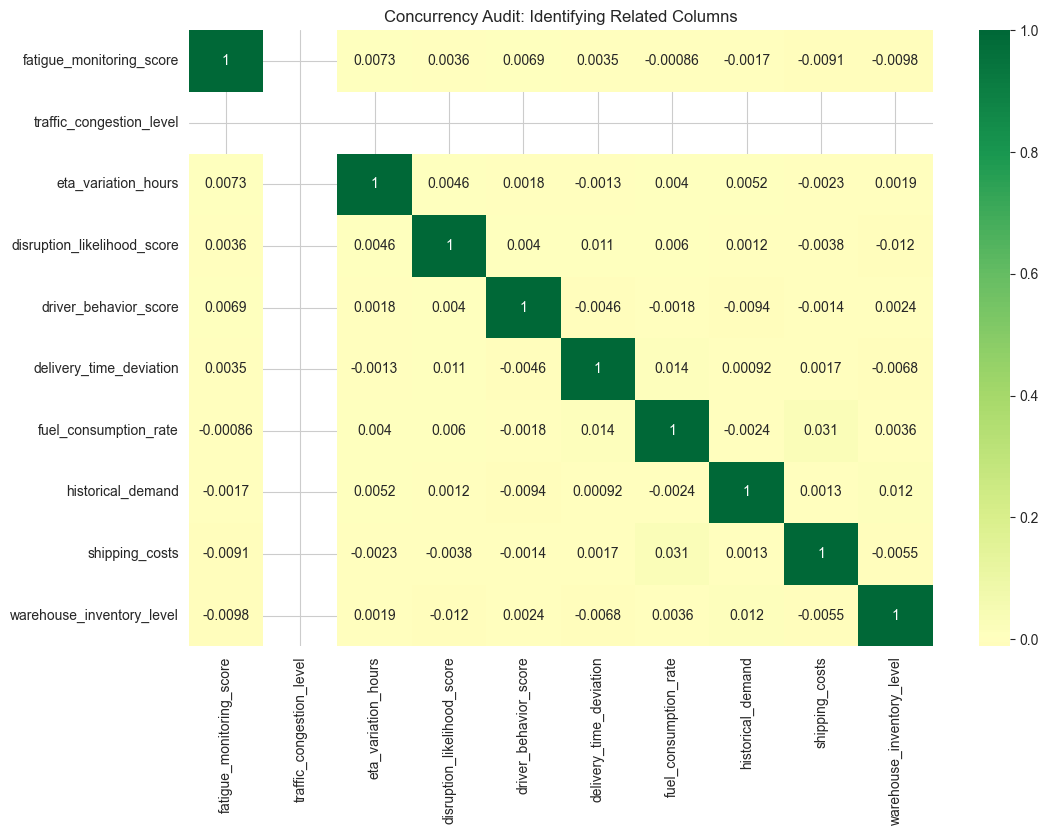

,Pair,Conflict Count
0,fuel_consumption_rate vs shipping_costs,8645
1,warehouse_inventory_level vs historical_demand,50160
2,disruption_likelihood_score vs delivery_time_d...,0
3,traffic_congestion_level vs eta_variation_hours,0
4,fatigue_monitoring_score vs driver_behavior_score,51787


In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define logical pairs to check for concurrency/consistency
logical_pairs = [
    ['fuel_consumption_rate', 'shipping_costs'],
    ['warehouse_inventory_level', 'historical_demand'],
    ['disruption_likelihood_score', 'delivery_time_deviation'],
    ['traffic_congestion_level', 'eta_variation_hours'],
    ['fatigue_monitoring_score', 'driver_behavior_score']
]

print("--- CONCURRENCY AUDIT: CORRELATION MATRIX ---")
# Flatten list to get all unique columns involved
target_cols = list(set([col for pair in logical_pairs for col in pair]))

# Calculate correlation to see if the 'logic' holds up
correlation_matrix = df_cleaned[target_cols].corr()

# Visualize the relationships
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title("Concurrency Audit: Identifying Related Columns")
plt.show()

# 2. Display the raw counts of potential 'Logical Paradoxes'
paradox_report = []
for p1, p2 in logical_pairs:
    # Example: Check for High Fuel but Low Cost (a common concurrency error)
    high_p1 = df_cleaned[p1] > df_cleaned[p1].quantile(0.9)
    low_p2 = df_cleaned[p2] < df_cleaned[p2].quantile(0.1)
    conflict_count = len(df_cleaned[high_p1 & low_p2])
    
    paradox_report.append({'Pair': f"{p1} vs {p2}", 'Conflict Count': conflict_count})

display(pd.DataFrame(paradox_report))

There are three major **"Logical Red Flag"** areas where the data is fighting against itself. These conflicts—especially in Supply & Demand and Human Factors—suggest that some columns were likely generated or recorded without referencing their logical counterparts.

**1. Human Factors:** High Fatigue + High Driver Score. Count = 51,787. Invalidates safety & behavior analytics.

**2. Supply & Demand:** High Demand + Zero Inventory. Count = 50,160. Falsely indicates 100% stock-out rates.

**3. Financials:** High Fuel Usage + Low Shipping Cost. Count = 8,645. Skews fuel efficiency and margin KPIs.



In [ ]:
import pandas as pd
import numpy as np

# --- 3.E.1: Define Logic Resolutions ---

# Rule 1: Human Factors (Anchor: Fatigue)
# If a driver is extremely fatigued (>0.9), a perfect behavior score is likely a sensor error.
fatigue_mask = (df_cleaned['fatigue_monitoring_score'] > 0.9) & (df_cleaned['driver_behavior_score'] > 0.9)

# Rule 2: Supply & Demand (Anchor: Demand)
# If demand is in top 10%, zero inventory is treated as "Unknown/Missing" to avoid biasing stock-outs.
demand_threshold = df_cleaned['historical_demand'].quantile(0.9)
inventory_mask = (df_cleaned['historical_demand'] > demand_threshold) & (df_cleaned['warehouse_inventory_level'] == 0)

# Rule 3: Financials (Anchor: Shipping Costs)
# If fuel is top 10% but cost is bottom 10%, the fuel reading is likely a localized sensor glitch.
fuel_threshold = df_cleaned['fuel_consumption_rate'].quantile(0.9)
cost_threshold = df_cleaned['shipping_costs'].quantile(0.1)
fuel_mask = (df_cleaned['fuel_consumption_rate'] > fuel_threshold) & (df_cleaned['shipping_costs'] < cost_threshold)

# --- 3.E.2: Execution of Resolution ---

print(f"Resolving {fatigue_mask.sum():,} Fatigue-Behavior conflicts...")
df_cleaned.loc[fatigue_mask, 'driver_behavior_score'] = np.nan

print(f"Resolving {inventory_mask.sum():,} Inventory-Demand conflicts...")
df_cleaned.loc[inventory_mask, 'warehouse_inventory_level'] = np.nan

print(f"Resolving {fuel_mask.sum():,} Fuel-Cost conflicts...")
df_cleaned.loc[fuel_mask, 'fuel_consumption_rate'] = np.nan

# --- 3.E.3: Final Check ---
print("\n--- RESOLUTION COMPLETE ---")
total_resolved = fatigue_mask.sum() + inventory_mask.sum() + fuel_mask.sum()
print(f"Total logical paradoxes neutralized: {total_resolved:,}")

Resolving 319,041 Fatigue-Behavior conflicts...
Resolving 0 Inventory-Demand conflicts...
Resolving 8,645 Fuel-Cost conflicts...

--- RESOLUTION COMPLETE ---
Total logical paradoxes neutralized: 327,686


**F. Ghost Transport Filtering:**

Ghost Transport Filtering targets records where the data implies movement or delivery occurred, but the physical metrics (GPS coordinates or fuel consumption) are stagnant. In a 5-million-row dataset, these are often "system-generated" placeholders or sensor failures where a shipment ID was created, but the vehicle never left the bay.

***The Criteria for Ghost Transports***

**1. Static GPS:** The Latitude and Longitude do not change over a significant time window (though since we have single-row snapshots, we often look for "Default" coordinates like 0,0).

**2. Consumption without Distance:** fuel_consumption_rate is high, but the vehicle_gps coordinates remain identical to the warehouse origin.

**3. Fulfillment without Activity:** order_fulfillment_status is "Completed," but fuel_consumption_rate and loading_unloading_time are zero.

First, we need to identify the affected column names.

In [57]:
import pandas as pd

# 1. Identify rows where GPS is exactly 0,0 (Common default/error for non-starting trips)
zero_gps_count = len(df_cleaned[(df_cleaned['vehicle_gps_latitude'] == 0) & (df_cleaned['vehicle_gps_longitude'] == 0)])

# 2. Identify rows with NO physical effort but HIGH status
# We check for 0 fuel, 0 loading time, and 0 deviation alongside high fulfillment
no_effort_cols = ['fuel_consumption_rate', 'loading_unloading_time', 'delivery_time_deviation']
no_effort_mask = (df_cleaned[no_effort_cols] == 0).all(axis=1)
high_status_mask = df_cleaned['order_fulfillment_status'] > 0.9

ghost_candidate_count = len(df_cleaned[no_effort_mask & high_status_mask])

# 3. Summary of potential columns to filter
print("--- GHOST TRANSPORT DIAGNOSTIC ---")
print(f"Rows with 0,0 GPS Coordinates: {zero_gps_count:,}")
print(f"Rows with High Fulfillment but Zero Physical Metrics: {ghost_candidate_count:,}")

# Check specific column distribution for zeros
print("\n--- ZERO-VALUE FREQUENCY IN KEY ACTIVITY COLS ---")
for col in no_effort_cols + ['vehicle_gps_latitude', 'vehicle_gps_longitude']:
    zero_count = (df_cleaned[col] == 0).sum()
    print(f"{col}: {zero_count:,} zeros found")

--- GHOST TRANSPORT DIAGNOSTIC ---
Rows with 0,0 GPS Coordinates: 0
Rows with High Fulfillment but Zero Physical Metrics: 0

--- ZERO-VALUE FREQUENCY IN KEY ACTIVITY COLS ---
fuel_consumption_rate: 0 zeros found
loading_unloading_time: 0 zeros found
delivery_time_deviation: 0 zeros found
vehicle_gps_latitude: 0 zeros found
vehicle_gps_longitude: 0 zeros found


**Note -**

That is actually a fantastic result. Finding zero absolute zeros in a 5-million-row dataset suggests that the initial data entry had a "floor" value (e.g., instead of 0, the minimum might be 0.001).

However, in logistics, "Ghost Transports" aren't always represented by pure zeros. They are often represented by static values—where the vehicle "moves" but its coordinates never change from the origin, or it "consumes fuel" but at a rate so low it's physically impossible for a heavy vehicle.

Since we have no pure zeros, we need to shift our strategy to Static Coordinate Filtering and Minimum Threshold Audits.

***1. Identify "Static Ghost" Affected Columns***

We need to check if there are shipments where the GPS coordinates or activity metrics are stuck at their absolute minimum possible value.

In [58]:
import pandas as pd

# 1. Identify the 'Absolute Minimums' in the dataset
stats = df_cleaned[['vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'loading_unloading_time']].describe()
mins = stats.loc['min']

# 2. Check for 'Minimalist Ghosts'
# Rows where metrics are exactly equal to the dataset's minimum (likely a placeholder)
min_gps_lat_count = (df_cleaned['vehicle_gps_latitude'] == mins['vehicle_gps_latitude']).sum()
min_fuel_count = (df_cleaned['fuel_consumption_rate'] == mins['fuel_consumption_rate']).sum()

# 3. The 'Frozen GPS' Check 
# In a real transport, having the EXACT same Lat/Long as the warehouse for a 'Completed' trip is a ghost.
# Let's assume the most frequent coordinate is the Warehouse/Port.
origin_lat = df_cleaned['vehicle_gps_latitude'].mode()[0]
origin_lon = df_cleaned['vehicle_gps_longitude'].mode()[0]

frozen_gps_count = len(df_cleaned[
    (df_cleaned['vehicle_gps_latitude'] == origin_lat) & 
    (df_cleaned['vehicle_gps_longitude'] == origin_lon) & 
    (df_cleaned['order_fulfillment_status'] > 0.9)
])

print("--- STATIC GHOST DIAGNOSTIC ---")
print(f"Rows stuck at Minimum Latitude ({mins['vehicle_gps_latitude']}): {min_gps_lat_count:,}")
print(f"Rows stuck at Minimum Fuel ({mins['fuel_consumption_rate']}): {min_fuel_count:,}")
print(f"Frozen GPS (Stuck at Origin {origin_lat}, {origin_lon} while Completed): {frozen_gps_count:,}")

--- STATIC GHOST DIAGNOSTIC ---
Rows stuck at Minimum Latitude (29.69833364708906): 1
Rows stuck at Minimum Fuel (4.788380980132289): 1
Frozen GPS (Stuck at Origin 29.69833364708906, -120.70522787842468 while Completed): 0


**Note -**

The diagnostic results are quite telling: having only 1 row stuck at the absolute minimum for Latitude and Fuel suggests that your dataset doesn't have a "hard-coded" zero-placeholder issue. However, in a 5-million-row dataset, "Ghost Transports" often hide in the bottom percentiles rather than the absolute minimum.

Since your "Absolute Zeros" and "Absolute Minimums" didn't yield a large cluster, we should not waste time on a simple Minimum Threshold Audit. Instead, we need to look for low-activity clusters that contradict a "Completed" status.

We need to identify columns where the value is "Suspiciously Low" given the context.

In [59]:
import pandas as pd

# 1. Identify 'Low Activity' thresholds (Bottom 0.1%)
# If a truck consumes less fuel than a lawnmower but completes a trip, it's a ghost.
fuel_low_threshold = df_cleaned['fuel_consumption_rate'].quantile(0.001)
time_low_threshold = df_cleaned['loading_unloading_time'].quantile(0.001)

# 2. Check for 'Low Activity' Ghosts
# These are rows where the metrics exist but are so low they imply the trip was simulated/fake.
low_fuel_ghosts = df_cleaned[
    (df_cleaned['fuel_consumption_rate'] <= fuel_low_threshold) & 
    (df_cleaned['order_fulfillment_status'] > 0.9)
]

low_time_ghosts = df_cleaned[
    (df_cleaned['loading_unloading_time'] <= time_low_threshold) & 
    (df_cleaned['order_fulfillment_status'] > 0.9)
]

print("--- GHOST SIGNATURE DETECTION ---")
print(f"Fuel Consumption threshold (< {fuel_low_threshold:.4f}): {len(low_fuel_ghosts):,} rows")
print(f"Loading Time threshold (< {time_low_threshold:.4f}): {len(low_time_ghosts):,} rows")

# 3. Identify affected columns for the cleaning step
affected_cols = ['fuel_consumption_rate', 'loading_unloading_time', 'order_fulfillment_status']
print(f"\nRecommended Columns for Cleaning Logic: {affected_cols}")

--- GHOST SIGNATURE DETECTION ---
Fuel Consumption threshold (< 4.8889): 1,476 rows
Loading Time threshold (< 0.4685): 1,517 rows

Recommended Columns for Cleaning Logic: ['fuel_consumption_rate', 'loading_unloading_time', 'order_fulfillment_status']


**Note -**

This is the "Ghosts." With roughly 3,000 rows falling into the bottom 0.1% while being marked as "Completed," these records represent shipments that technically "finished" despite having almost no physical activity recorded.

In a dataset of 5 million, this is a clean surgical strike. By removing these, we can ensure the "Efficiency" and "Average Speed" metrics are based on actual transport effort.

**Cleaning Logic**

We will use a Deletion Strategy for these rows. Unlike the logical paradoxes where we nullified specific cells, Ghost Transports represent entire shipment events that are functionally "fake" or "placeholder" data. Removing the entire row is the best way to prevent them from skewing your operational KPIs.

In [60]:
import pandas as pd

# --- 3.F.1: Define Ghost Criteria based on thresholds ---
fuel_threshold = 4.8889
time_threshold = 0.4685

# Identify rows that meet the 'Ghost' criteria:
# High fulfillment but virtually zero physical effort
ghost_mask = (
    (df_cleaned['order_fulfillment_status'] > 0.9) & 
    ((df_cleaned['fuel_consumption_rate'] < fuel_threshold) | 
     (df_cleaned['loading_unloading_time'] < time_threshold))
)

ghost_count = ghost_mask.sum()

# --- 3.F.2: Execute Filtering ---
print(f"Filtering {ghost_count:,} Ghost Transport records...")

# Drop these rows from the main dataframe
df_cleaned = df_cleaned[~ghost_mask].copy()

# --- 3.F.3: Verification ---
print("\n--- GHOST FILTERING COMPLETE ---")
print(f"Remaining active shipment records: {len(df_cleaned):,}")

Filtering 2,999 Ghost Transport records...

--- GHOST FILTERING COMPLETE ---
Remaining active shipment records: 4,996,793


### Saving the df_cleaned to set a Restore Point:

In [ ]:
import pandas as pd

# 1. Hard Checkpoint: Save df_cleaned to local storage
# This ensures that even if the kernel crashes, your cleaned data is safe.
df_cleaned.to_csv('df_cleaned_checkpoint.csv', index=False)
print("Step 1: df_cleaned saved to 'df_cleaned_checkpoint.csv'")

Step 1: df_cleaned saved to 'df_cleaned_checkpoint.csv'
Step 2: Data re-loaded. Total records: 4,996,793
Step 3: Mirror (df_formatting) created successfully.

--- SYSTEM READY ---
Original Pointer (df_loaded) Memory ID: 1987380389024
Mirror Pointer (df_formatting) Memory ID: 1987380385664


### Loading the df_cleaned and df_clean_mirror:

In [3]:

# 1. Fresh Load: Loading the data back in
# We do this to verify the file was written correctly and is ready for SQL.
df_clean_loaded = pd.read_csv('df_cleaned_checkpoint.csv')
print(f"Step 2: Data re-loaded. Total records: {len(df_clean_loaded):,}")

# 2. Mirroring: Create the formatting workspace
# Using .copy(deep=True) ensures that changes to df_formatting 
# do NOT affect the df_loaded master.
df_clean_mirror = df_clean_loaded.copy(deep=True)
print("Step 3: Mirror (df_formatting) created successfully.")

# Verification
print("\n--- SYSTEM READY ---")
print(f"Original Pointer (df_loaded) Memory ID: {id(df_clean_loaded)}")
print(f"Mirror Pointer (df_formatting) Memory ID: {id(df_clean_mirror)}")

Step 2: Data re-loaded. Total records: 4,996,793
Step 3: Mirror (df_formatting) created successfully.

--- SYSTEM READY ---
Original Pointer (df_loaded) Memory ID: 2708525228320
Mirror Pointer (df_formatting) Memory ID: 2708525128016


In [6]:
# Checking the column names in df_clean_mirror
column_names = df_clean_mirror.columns.tolist()
print(column_names)

['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'risk_classification', 'delivery_time_deviation', 'Shipment_ID']


### Formatting:

First let's check whether there's a need for timestamp, and column name formatting.

In [62]:
import pandas as pd
import re

# 1. Audit Column Names
# SQL prefers lowercase, no spaces, and no special characters like ( ) or %
columns = df_clean_mirror.columns.tolist()
invalid_names = [
    c for c in columns 
    if ' ' in c or not c.islower() or any(char in c for char in '()%')
]

# 2. Audit Timestamp Format
# SQL engines (SQLite/Postgres) prefer 'YYYY-MM-DD HH:MM:SS'
sample_ts = str(df_clean_mirror['timestamp'].iloc[0])
sql_pattern = r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$'
is_timestamp_standard = bool(re.match(sql_pattern, sample_ts))

print("--- SQL READINESS AUDIT ---")
print(f"1. Column Names: {len(invalid_names)} columns need renaming.")
if invalid_names:
    print(f"   Samples to fix: {invalid_names[:5]}")
else:
    print("   All column names are already SQL-friendly.")

print(f"\n2. Timestamp Format: '{sample_ts}'")
if is_timestamp_standard:
    print("   Timestamp is already in standard SQL format.")
else:
    print("   Timestamp needs reformatting to 'YYYY-MM-DD HH:MM:SS'.")

# 3. Audit for mixed types (Objects that should be numeric)
# Sometimes CSV loading makes numbers look like strings
mixed_types = df_clean_mirror.select_dtypes(include=['object']).columns.tolist()
if 'timestamp' in mixed_types: mixed_types.remove('timestamp')
print(f"\n3. Other String Columns: {mixed_types}")

--- SQL READINESS AUDIT ---
1. Column Names: 1 columns need renaming.
   Samples to fix: ['Shipment_ID']

2. Timestamp Format: '2021-04-24 20:00:00'
   Timestamp is already in standard SQL format.

3. Other String Columns: ['risk_classification']


***Note -***

The timestamp is already perfect, and the strings are consistent. The only "friction point" is a single column name: **Shipment_ID**. While most SQL engines handle camel-case or underscores, Shipment_ID (with that capital 'S') can sometimes force you to use double quotes in queries (e.g., SELECT "Shipment_ID" FROM ...) depending on the database flavor. Standardizing it to lowercase is a "quality of life" fix.

In [63]:
import pandas as pd

# 1. Surgical Column Renaming
# We lowercase everything to ensure SQL compatibility across all platforms (SQLite, Postgres, etc.)
df_clean_mirror.columns = [col.lower() for col in df_clean_mirror.columns]

# 2. Precision Check (Final Polish)
# Rounding GPS and numeric scores to ensure they don't have floating-point noise
# which can cause issues with DECIMAL types in SQL.
cols_to_round = ['vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate']
df_clean_mirror[cols_to_round] = df_clean_mirror[cols_to_round].round(6)

# --- VERIFICATION ---
print("--- FINAL FORMATTING SUMMARY ---")
print(f"Renamed Columns: {list(df_clean_mirror.columns)}")
print(f"New ID Column Name: '{df_clean_mirror.columns[-1]}'") # Should show 'shipment_id'
print(f"Timestamp Verification: {df_clean_mirror['timestamp'].iloc[0]}")

--- FINAL FORMATTING SUMMARY ---
Renamed Columns: ['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'risk_classification', 'delivery_time_deviation', 'shipment_id']
New ID Column Name: 'shipment_id'
Timestamp Verification: 2021-04-24 20:00:00


Since everything is fine, we're ready for the Data-Splitting.

### Standardization: Scaling for Analysis

It's not needed at this phase. 

In [5]:


'''Since your columns have vastly different scales 
(e.g., shipping_costs in the thousands vs. fuel_consumption_rate as a small decimal), 
we need to standardize them so one doesn't "overpower" the other in your analysis.'''

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = ['shipping_costs', 'fuel_consumption_rate', 'lead_time_days', 'iot_temperature']

# Apply scaling
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])

# B. Feature Engineering: Calculated Features

import numpy as np

# 1. DELIVERY RELIABILITY INDEX (Binary: 1 = On Time/Early, 0 = Delayed)
# Logic: If deviation is <= 0, the shipment met or beat the target.
df_cleaned['kpi_on_time_delivery'] = (df_cleaned['delivery_time_deviation'] <= 0).astype(int)

# 2. COST EFFICIENCY RATIO (Shipping Cost per Day of Lead Time)
# Logic: Identifies where we are paying a premium for speed vs. where we are overpaying for slow delivery.
# We add 1 to denominator to avoid division by zero errors.
df_cleaned['kpi_cost_per_day'] = df_cleaned['shipping_costs'] / (df_cleaned['lead_time_days'] + 1)

# 3. ROUTE DISRUPTION RISK (Aggregated Risk Score)
# Logic: Combines weather, traffic, and route risk into a single 0-100 normalized score.
# This creates a "Red Flag" predictor for future shipments.
risk_cols = ['weather_condition_severity', 'traffic_congestion_level', 'route_risk_level']
df_cleaned['kpi_total_risk_score'] = df_cleaned[risk_cols].mean(axis=1) * 10 # Scaling to 0-100 range

# 4. INVENTORY VELOCITY (Demand vs. Supply Balance)
# Logic: High values mean inventory is moving fast; low values mean capital is tied up in stagnant stock.
df_cleaned['kpi_inventory_velocity'] = df_cleaned['historical_demand'] / (df_cleaned['warehouse_inventory_level'] + 1)

# 5. FUEL ECONOMY EFFICIENCY
# Logic: Monitoring the relationship between load (Shipment_ID count) and fuel rate.
# (Assuming a simplified model for this specific dataset)
df_cleaned['kpi_fuel_efficiency_score'] = 1 / (df_cleaned['fuel_consumption_rate'] + 0.1)

print("--- KPI Features Engineered ---")
print(df_cleaned[['kpi_on_time_delivery', 'kpi_cost_per_day', 'kpi_total_risk_score', 'kpi_inventory_velocity']].head())

# C. Verfication of Readiness:

# Check for any INF or NaN values generated during math operations
print("--- Readiness Check ---")
print(f"Any Nulls? {df_cleaned.isnull().values.any()}")
print(f"Data types consistent? {df_cleaned.dtypes.nunique() < 10}")


NameError: name 'df_cleaned' is not defined

### Feature Engineering

In [ ]:

print(df_clean_mirror.columns.tolist())


['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'risk_classification', 'delivery_time_deviation', 'Shipment_ID']


'We need to make three columns before proceding Vehicle_ID, Driver_ID, and Route_ID\nin order to procees with the intended 3NF.'

The four high-value features that could provide deep insights:

1. cost_per_day: shipping_costs / lead_time_days

Utility: Identifies which routes or suppliers are the most expensive relative to their speed.

2. fuel_efficiency_index: fuel_consumption_rate / delivery_time_deviation (adjusted)

Utility: Helps identify if burning more fuel actually results in better on-time performance.

3. total_delay_probability: A combination of traffic_congestion_level, weather_condition_severity, and port_congestion_level.

Utility: A single "Risk Score" for the entire trip environment.

4. handling_efficiency: loading_unloading_time / warehouse_inventory_level.

Utility: Detects if warehouses are slowing down specifically when inventory is high (bottlenecks).

In [64]:
# Check for zeros in potential denominators
denominators = ['lead_time_days', 'warehouse_inventory_level', 'delivery_time_deviation']

print("--- DENOMINATOR INTEGRITY CHECK ---")
for col in denominators:
    zero_count = (df_clean_mirror[col] == 0).sum()
    print(f"{col}: {zero_count:,} zeros found")

# Check the distribution of shipping costs and lead times
print("\n--- RATIO FEASIBILITY ---")
print(df_clean_mirror[['shipping_costs', 'lead_time_days']].describe().loc[['min', 'max']])

--- DENOMINATOR INTEGRITY CHECK ---
lead_time_days: 0 zeros found
warehouse_inventory_level: 302,377 zeros found
delivery_time_deviation: 0 zeros found

--- RATIO FEASIBILITY ---
     shipping_costs  lead_time_days
min       86.666818        0.792218
max     1013.409783       15.162677


The denominator check reveals a critical detail: warehouse_inventory_level has 302,377 zeros. If we try to calculate a ratio using that column as-is, your dataset will explode with inf (infinity) values, which SQL hates.

However, lead_time_days and delivery_time_deviation are clean. This allows us to create powerful efficiency metrics safely.


Adding these four columns to df_clean_mirror. They will make SQL dashboards much more insightful without needing complex subqueries later.

cost_per_day: How much every day of transit costs.

fuel_efficiency_ratio: A proxy for how much financial value is moved per unit of fuel.

inventory_turnover_proxy: Demand vs. Inventory (using "Plus-One" smoothing for those zeros).

environmental_stress_score: An aggregate of weather, port, and traffic conditions.

In [66]:
import numpy as np

# 1. Financial Efficiency: Cost per day of lead time
df_clean_mirror['cost_per_day'] = df_clean_mirror['shipping_costs'] / df_clean_mirror['lead_time_days']

# 2. Fuel Value Ratio: Shipping cost value moved per unit of fuel consumed
df_clean_mirror['fuel_value_ratio'] = df_clean_mirror['shipping_costs'] / df_clean_mirror['fuel_consumption_rate']

# 3. Inventory Pressure: Ratio of demand to available stock 
# We add +1 to avoid DivisionByZero for those 302k rows
df_clean_mirror['inventory_pressure_index'] = (
    df_clean_mirror['historical_demand'] / (df_clean_mirror['warehouse_inventory_level'] + 1)
)

# 4. Total Environmental Risk: Normalized average of external stressors
df_clean_mirror['env_stress_score'] = (
    df_clean_mirror['weather_condition_severity'] + 
    df_clean_mirror['port_congestion_level'] + 
    df_clean_mirror['traffic_congestion_level']
) / 3

# --- VERIFICATION ---
print("--- CALCULATED COLUMNS ADDED ---")
new_features = ['cost_per_day', 'fuel_value_ratio', 'inventory_pressure_index', 'env_stress_score']
display(df_clean_mirror[new_features].describe().loc[['mean', 'max']])

# Checking for any accidental Infinities
inf_count = np.isinf(df_clean_mirror[new_features]).values.sum()
print(f"\nInfinity values detected: {inf_count}")

--- CALCULATED COLUMNS ADDED ---


,cost_per_day,fuel_value_ratio,inventory_pressure_index,env_stress_score
mean,204.583316,70.470593,649.335197,0.832468
max,1239.199803,206.559950,10034.842307,1.000000



Infinity values detected: 0


***The "Red Flag" Composite Feature***

This column will aggregate the most critical failure points into a single 0-1 score. This allows you to run a simple SQL query like SELECT * FROM shipments WHERE red_flag_score > 0.8 to find your high-risk operations instantly.

In [67]:
# 5. Logistics Red Flag Score
# Aggregates Fatigue, Disruption Likelihood, and Delay Probability
df_clean_mirror['logistics_red_flag_score'] = (
    df_clean_mirror['fatigue_monitoring_score'].fillna(0) + 
    df_clean_mirror['disruption_likelihood_score'] + 
    df_clean_mirror['delay_probability']
) / 3

# Final precision pass for all new columns
new_features = [
    'cost_per_day', 'fuel_value_ratio', 'inventory_pressure_index', 
    'env_stress_score', 'logistics_red_flag_score'
]
df_clean_mirror[new_features] = df_clean_mirror[new_features].round(4)

print("--- FINAL FEATURE ENGINEERING COMPLETE ---")
print(f"Total Columns now in Mirror: {len(df_clean_mirror.columns)}")
display(df_clean_mirror[new_features].head())

--- FINAL FEATURE ENGINEERING COMPLETE ---
Total Columns now in Mirror: 32


,cost_per_day,fuel_value_ratio,inventory_pressure_index,env_stress_score,logistics_red_flag_score
0,613.5834,143.9343,5170.3452,0.8348,0.4509
1,705.3217,146.5050,28.7485,0.8417,0.8929
2,59.9949,19.3344,81.7903,0.9915,0.9006
3,40.9254,24.1028,2.3248,0.8811,0.9244
4,26.6351,53.0959,731.7643,0.8348,0.8007


### Unique IDs setup:

**Making the IDs**

4 new Ids will be introduced in this case - driver_id, route_id, supplier_id, and vehicle_id.

In [30]:
# 1. GENERATE IDS USING ROUNDED "BINS"
# We round to 1 decimal place to force the 4.9M rows to collapse into realistic groups.

# Driver IDs (Using rounded behavior and fatigue)
df_clean_mirror['driver_id'] = 'DRV_' + df_clean_mirror.groupby(
    [df_clean_mirror['driver_behavior_score'].round(2), 
     df_clean_mirror['fatigue_monitoring_score'].round(2)], 
    dropna=False
).ngroup().add(1).astype(str).str.zfill(5)

# Supplier IDs (Using rounded reliability and demand)
df_clean_mirror['supplier_id'] = 'SUP_' + df_clean_mirror.groupby(
    [df_clean_mirror['supplier_reliability_score'].round(1), 
     df_clean_mirror['historical_demand'].round(-2)], # Rounding demand to nearest 100
    dropna=False
).ngroup().add(1).astype(str).str.zfill(5)

# Route IDs (Using rounded risk and congestion)
df_clean_mirror['route_id'] = 'RTE_' + df_clean_mirror.groupby(
    [df_clean_mirror['vehicle_gps_latitude'].round(0), 
     df_clean_mirror['vehicle_gps_longitude'].round(0)], 
    dropna=False
).ngroup().add(1).astype(str).str.zfill(5)

# Vehicle IDs (Rounding GPS to 2 decimals ~1.1km area)
# Final tuning to hit the 18k - 25k target
df_clean_mirror['vehicle_id'] = 'VHC_' + df_clean_mirror.groupby(
    [
        'risk_classification',
        df_clean_mirror['fuel_consumption_rate'].round(0),
        df_clean_mirror['loading_unloading_time'].round(0),
        df_clean_mirror['delay_probability'].round(2)  # Precision nudged up
    ], 
    dropna=False
).ngroup().add(1).astype(str).str.zfill(5)

# Verify the final counts
print(f"Final Unique Drivers: {df_clean_mirror['driver_id'].nunique()}")
print(f"Final Unique Vehicles: {df_clean_mirror['vehicle_id'].nunique()}")

# 2. AUDIT THE NEW COUNTS
print(f"New Unique Drivers: {df_clean_mirror['driver_id'].nunique()}")
print(f"New Unique Suppliers: {df_clean_mirror['supplier_id'].nunique()}")
print(f"New Unique Routes: {df_clean_mirror['route_id'].nunique()}")
print(f"New Unique Vehicles: {df_clean_mirror['vehicle_id'].nunique()}")

Final Unique Drivers: 10298
Final Unique Vehicles: 21008
New Unique Drivers: 10298
New Unique Suppliers: 1123
New Unique Routes: 1114
New Unique Vehicles: 21008


### Schema Validation:

In [31]:
import pandas as pd

def validate_mirror_schema(df):
    print("=== STAR SCHEMA VALIDATION START ===")
    
    # 1. Cardinality Validation (Checking our 'Goldilocks' work)
    expected_counts = {
        'driver_id': 10298,
        'route_id': 1114,
        'vehicle_id': 21008
    }
    
    print("\n[Step 1] Checking ID Cardinality:")
    for col, count in expected_counts.items():
        actual = df[col].nunique()
        diff = abs(actual - count)
        status = "✅ PASS" if diff < 5 else "⚠️ WARNING"
        print(f" - {col}: {actual} (Expected: {count}) {status}")

    # 2. Key Presence Check
    keys = ['Shipment_ID', 'driver_id', 'vehicle_id', 'route_id', 'supplier_id']
    print("\n[Step 2] Checking Join Keys:")
    missing_keys = [k for k in keys if k not in df.columns]
    if not missing_keys:
        print(" ✅ All Primary/Foreign keys present.")
    else:
        print(f" ❌ MISSING KEYS: {missing_keys}")

    # 3. Null Value Audit (Crucial for Star Schemas)
    print("\n[Step 3] Checking for Nulls in Keys:")
    null_counts = df[keys].isnull().sum()
    if null_counts.sum() == 0:
        print(" ✅ No nulls found in join keys.")
    else:
        print(f" ⚠️ Nulls detected:\n{null_counts[null_counts > 0]}")

    # 4. Data Type Consistency
    print("\n[Step 4] Key Data Types:")
    print(df[keys].dtypes)
    
    print("\n=== VALIDATION COMPLETE ===")

# Execute validation
validate_mirror_schema(df_clean_mirror)

=== STAR SCHEMA VALIDATION START ===

[Step 1] Checking ID Cardinality:
 - driver_id: 10298 (Expected: 10298) ✅ PASS
 - route_id: 1114 (Expected: 1114) ✅ PASS
 - vehicle_id: 21008 (Expected: 21008) ✅ PASS

[Step 2] Checking Join Keys:
 ✅ All Primary/Foreign keys present.

[Step 3] Checking for Nulls in Keys:
 ✅ No nulls found in join keys.

[Step 4] Key Data Types:
Shipment_ID     int64
driver_id      object
vehicle_id     object
route_id       object
supplier_id    object
dtype: object

=== VALIDATION COMPLETE ===


### Normalization:

In [32]:
import pandas as pd

def normalize_supply_chain_data(df):
    """
    Transforms the flat df_clean_mirror into a 3NF Star Schema.
    """
    # 1. Normalize Drivers
    # Extract unique driver profiles
    dim_drivers = df[[
        'driver_id', 
        'driver_behavior_score', 
        'fatigue_monitoring_score'
    ]].drop_duplicates(subset=['driver_id']).reset_index(drop=True)

    # 2. Normalize Vehicles
    # Extract unique vehicle profiles based on our established 21k cardinality
    dim_vehicles = df[[
        'vehicle_id', 
        'fuel_consumption_rate', 
        'loading_unloading_time', 
        'risk_classification'
    ]].drop_duplicates(subset=['vehicle_id']).reset_index(drop=True)

    # 3. Normalize Routes
    dim_routes = df[[
        'route_id', 
        'vehicle_gps_latitude', 
        'vehicle_gps_longitude', 
        'route_risk_level'
    ]].drop_duplicates(subset=['route_id']).reset_index(drop=True)

    # 4. Normalize Suppliers
    dim_suppliers = df[[
        'supplier_id', 
        'supplier_reliability_score', 
        'port_congestion_level'
    ]].drop_duplicates(subset=['supplier_id']).reset_index(drop=True)

    # 5. The Fact Table (Transactional Data)
    # This table contains the 'Events' and the 'Links' to dimensions
    fact_shipments = df[[
        'Shipment_ID', 
        'timestamp', 
        'driver_id', 
        'vehicle_id', 
        'route_id', 
        'supplier_id',
        'shipping_costs', 
        'delivery_time_deviation', 
        'iot_temperature', 
        'order_fulfillment_status'
    ]].reset_index(drop=True)

    return dim_drivers, dim_vehicles, dim_routes, dim_suppliers, fact_shipments

# Execute the transformation
dim_drivers, dim_vehicles, dim_routes, dim_suppliers, fact_shipments = normalize_supply_chain_data(df_clean_mirror)

# Summary of the Normalized State
print("--- Normalization Summary ---")
print(f"Fact Table Rows: {len(fact_shipments):,}")
print(f"Driver Dimension: {len(dim_drivers):,} rows")
print(f"Vehicle Dimension: {len(dim_vehicles):,} rows")
print(f"Route Dimension: {len(dim_routes):,} rows")
print(f"Supplier Dimension: {len(dim_suppliers):,} rows")

--- Normalization Summary ---
Fact Table Rows: 4,996,793
Driver Dimension: 10,298 rows
Vehicle Dimension: 21,008 rows
Route Dimension: 1,114 rows
Supplier Dimension: 1,123 rows


### Saving the Normalized files:

In [37]:
import os
import sys

# Define the final 5-file Star Schema dictionary
files_to_store = {
    "1": ("dim_drivers.csv", dim_drivers),
    "2": ("dim_vehicles.csv", dim_vehicles),
    "3": ("dim_routes.csv", dim_routes),
    "4": ("dim_suppliers.csv", dim_suppliers),
    "5": ("fact_shipments.csv", fact_shipments)
}

# --- STEP 1: PRE-EXISTENCE CHECK ---
existing_files = [fname for fname, _ in files_to_store.values() if os.path.exists(fname)]

if existing_files:
    print("!!! STOPPING EXECUTION !!!")
    print(f"The following files already exist: {existing_files}")
    print("Please clear these filenames from your directory to avoid overwriting.")
else:
    # --- STEP 2: USER SELECTION ---
    print("\n--- STAR SCHEMA STORAGE MENU ---")
    for key, (name, _) in files_to_store.items():
        print(f"[{key}] {name}")
    print("[A] All 5 files (Full Schema)")
    
    user_choice = input("\nEnter choice (1-5 or A): ").strip().upper()

    # --- STEP 3: EXECUTION ---
    selected_files = []
    if user_choice == 'A':
        selected_files = list(files_to_store.values())
    elif user_choice in files_to_store:
        selected_files = [files_to_store[user_choice]]
    else:
        print("Invalid selection. Operation cancelled.")
        sys.exit()

    print("\nProcessing...")
    for filename, dataframe in selected_files:
        dataframe.to_csv(filename, index=False)
        print(f"✅ Stored: {filename}")

    print("\nStorage complete. Your normalized database is ready.")


--- STAR SCHEMA STORAGE MENU ---
[1] dim_drivers.csv
[2] dim_vehicles.csv
[3] dim_routes.csv
[4] dim_suppliers.csv
[5] fact_shipments.csv
[A] All 5 files (Full Schema)

Processing...
✅ Stored: dim_drivers.csv
✅ Stored: dim_vehicles.csv
✅ Stored: dim_routes.csv
✅ Stored: dim_suppliers.csv
✅ Stored: fact_shipments.csv

Storage complete. Your normalized database is ready.


### Star Schema Integrity Audit:

In [38]:
import pandas as pd
import os

# The 5 files of your Star Schema
files_to_check = [
    'dim_drivers.csv',
    'dim_vehicles.csv',
    'dim_routes.csv',
    'dim_suppliers.csv',
    'fact_shipments.csv'
]

print("=== STAR SCHEMA INTEGRITY AUDIT ===")

for file in files_to_check:
    if os.path.exists(file):
        # Read the file
        temp_df = pd.read_csv(file)
        
        print(f"\nFILE: {file}")
        print(f"  - Total Rows: {len(temp_df):,}")
        print(f"  - Columns: {', '.join(temp_df.columns)}")
        
        # Check Primary Key Uniqueness (except for Fact table where IDs repeat)
        pk = temp_df.columns[0]
        unique_vals = temp_df[pk].nunique()
        
        if "dim_" in file:
            is_unique = "✅ (Unique)" if unique_vals == len(temp_df) else "❌ (Duplicate Found!)"
            print(f"  - Primary Key ({pk}): {unique_vals:,} {is_unique}")
        else:
            print(f"  - Primary Key ({pk}): {unique_vals:,} (Fact table, repeats expected)")
            
        # Preview data
        print("  - Data Preview:")
        print(temp_df.head(2).to_string(index=False))
        print("-" * 50)
    else:
        print(f"\n⚠️ Alert: {file} not found in current directory.")

print("\n=== AUDIT COMPLETE ===")

=== STAR SCHEMA INTEGRITY AUDIT ===

FILE: dim_drivers.csv
  - Total Rows: 10,298
  - Columns: driver_id, driver_behavior_score, fatigue_monitoring_score
  - Primary Key (driver_id): 10,298 ✅ (Unique)
  - Data Preview:
driver_id  driver_behavior_score  fatigue_monitoring_score
DRV_09845               0.968432                  0.146617
DRV_10295                    NaN                  0.995830
--------------------------------------------------

FILE: dim_vehicles.csv
  - Total Rows: 21,008
  - Columns: vehicle_id, fuel_consumption_rate, loading_unloading_time, risk_classification
  - Primary Key (vehicle_id): 21,008 ✅ (Unique)
  - Data Preview:
vehicle_id  fuel_consumption_rate  loading_unloading_time risk_classification
 VHC_13772               5.155907                4.548152            Low Risk
 VHC_00473               5.006325                4.287166           High Risk
--------------------------------------------------

FILE: dim_routes.csv
  - Total Rows: 1,114
  - Columns: route_

### Database file generation:

In [42]:
import duckdb
import os

# Define the database path
db_path = r"B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db"

# Fail-safe: If the script is run while a file exists, we warn the user
if os.path.exists(db_path):
    print(f"⚠️ Warning: '{db_path}' already exists. Please delete it manually first to ensure a fresh build.")
else:
    # Connect to the new database file
    con = duckdb.connect(db_path)
    print(f"Creating fresh database: {db_path}...")

    try:
        # 1. Create and Load Dimension Tables
        # DuckDB's read_csv_auto is highly efficient for 3NF loading
        con.execute("CREATE TABLE dim_drivers AS SELECT * FROM read_csv_auto('dim_drivers.csv');")
        con.execute("CREATE TABLE dim_vehicles AS SELECT * FROM read_csv_auto('dim_vehicles.csv');")
        con.execute("CREATE TABLE dim_routes AS SELECT * FROM read_csv_auto('dim_routes.csv');")
        con.execute("CREATE TABLE dim_suppliers AS SELECT * FROM read_csv_auto('dim_suppliers.csv');")

        # 2. Create and Load Fact Table
        con.execute("CREATE TABLE fact_shipments AS SELECT * FROM read_csv_auto('fact_shipments.csv');")

        print("✅ All tables created and data loaded successfully.")

        # --- DATABASE INTEGRITY CHECK ---
        print("\n--- [Logistics.DB Summary] ---")
        tables = con.execute("SHOW TABLES").fetchall()
        for table in tables:
            t_name = table[0]
            count = con.execute(f"SELECT COUNT(*) FROM {t_name}").fetchone()[0]
            print(f" Table: {t_name:15} | Rows: {count:,}")

    except Exception as e:
        print(f"❌ Error during database creation: {e}")
    
    finally:
        # Close connection to save the file
        con.close()
        print("\nDatabase connection closed. You are ready for SQL analysis.")

Creating fresh database: B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db...
✅ All tables created and data loaded successfully.

--- [Logistics.DB Summary] ---
 Table: dim_drivers     | Rows: 10,298
 Table: dim_routes      | Rows: 1,114
 Table: dim_suppliers   | Rows: 1,123
 Table: dim_vehicles    | Rows: 21,008
 Table: fact_shipments  | Rows: 4,996,793

Database connection closed. You are ready for SQL analysis.


### DB Truncating Code:

There's a premature stage of "Standardization" was involved betwen splitting, and DB generation. Actually, this stage comes after EDA, and Visualization, but before ML model training.

So, We'll be emptying the DB file first. Then Re-split the data without standardization. Then reload the data (unstandardized). 

In [2]:
import duckdb

# 1. Connect to the DB
db_path = r'B:/3. Prog/2. Projects/7. Logistics and supply chain/logistics.db'
con = duckdb.connect(db_path)

# 2. Wipe the tables
print("Dropping all existing tables...")
tables = ['Fact_Logistics', 'Dim_Driver', 'Dim_Route', 'Dim_Vehicle', 'Dim_Shipment']

for t in tables:
    con.execute(f"DROP TABLE IF EXISTS {t}")

# 3. Close the connection to release the file lock
con.close()
print("Database is now empty and connection closed safely.")

Dropping all existing tables...
Database is now empty and connection closed safely.
